# PHASE 1: BUILDING THE ATTRIBUTION FRAMEWORK

## 1. Bot Detection

In [4]:
nbconvert[webpdf]

NameError: name 'webpdf' is not defined

In [1]:
import pandas as pd
import numpy as np


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Mastm\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Mastm\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Mastm\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Mastm\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
funnel_rank = {'Impression': 1, 'Click': 2, 'Add-to-Cart': 3, 'Purchase': 4}

In [3]:
# ---------------------------------------------------------
# 0. LOAD DATA
# ---------------------------------------------------------
touch = pd.read_csv('touchpoints.csv')
profiles = pd.read_csv('user_profiles.csv')

touch['Timestamp'] = pd.to_datetime(touch['Timestamp'], format='%m/%d/%Y %H:%M')
touch = touch.sort_values(['User_ID', 'Timestamp']).reset_index(drop=True)

print("Total events:", len(touch))
print("Total unique users:", touch['User_ID'].nunique())
print(touch['Event_Type'].value_counts())

Total events: 566510
Total unique users: 100000
Event_Type
Impression     439694
Click          118191
Purchase         5498
Add-to-Cart      3127
Name: count, dtype: int64


In [4]:

# ---------------------------------------------------------
# Base per-user aggregates (needed across all 4 cases)
# ---------------------------------------------------------
agg = touch.groupby('User_ID').agg(
    total_events=('Event_Type', 'count'),
    n_impressions=('Event_Type', lambda x: (x == 'Impression').sum()),
    n_clicks=('Event_Type', lambda x: (x == 'Click').sum()),
    n_purchases=('Event_Type', lambda x: (x == 'Purchase').sum()),
).reset_index()


In [5]:
# ---------------------------------------------------------
# CASE 1: High Touchpoints + No Purchase
# "High" = top 1% of total_events among users with zero purchases
# ---------------------------------------------------------
no_purchase = agg[agg['n_purchases'] == 0]
case1_thresh = no_purchase['total_events'].quantile(0.99)
case1_users = set(no_purchase.loc[no_purchase['total_events'] > case1_thresh, 'User_ID'])

print(f"Case 1 threshold (events): {case1_thresh:.1f}")
print(f"Case 1 flagged users: {len(case1_users)}")


Case 1 threshold (events): 100.0
Case 1 flagged users: 917


C:\Users\Mastm\AppData\Local\Temp\ipykernel_8696\2151745867.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(agg['total_events'], vert=False)


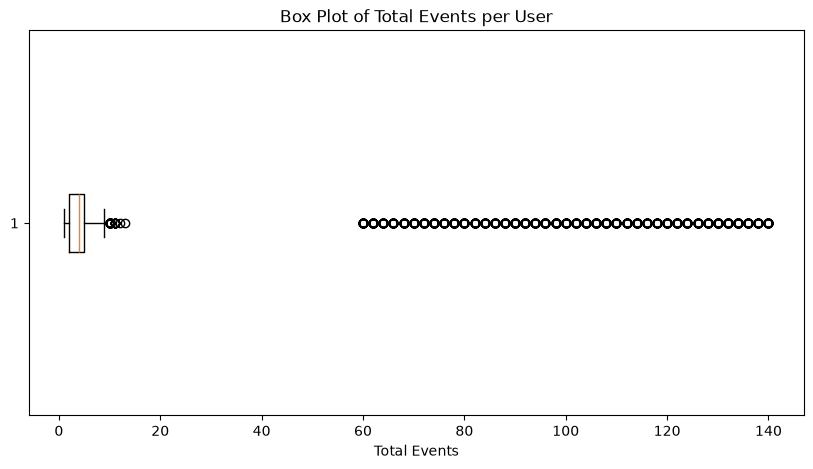

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.boxplot(agg['total_events'], vert=False)

plt.title('Box Plot of Total Events per User')
plt.xlabel('Total Events')
plt.show()

In [7]:
Q1 = agg['total_events'].quantile(0.25)
Q3 = agg['total_events'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = agg[(agg['total_events'] < lower) |
               (agg['total_events'] > upper)]

print("Number of Outliers:", len(outliers))
display(outliers.sort_values('total_events', ascending=False))

Number of Outliers: 2028


,User_ID,total_events,n_impressions,n_clicks,n_purchases
85315,U_B09_05315,140,70,70,0
29200,U_B03_09200,140,70,70,0
26203,U_B03_06203,140,70,70,0
85408,U_B09_05408,140,70,70,0
25133,U_B03_05133,140,70,70,0
...,...,...,...,...,...
1952,U_B01_01952,10,6,2,1
1065,U_B01_01065,10,6,2,0
63050,U_B07_03050,10,6,3,1
99211,U_B10_09211,10,6,3,0


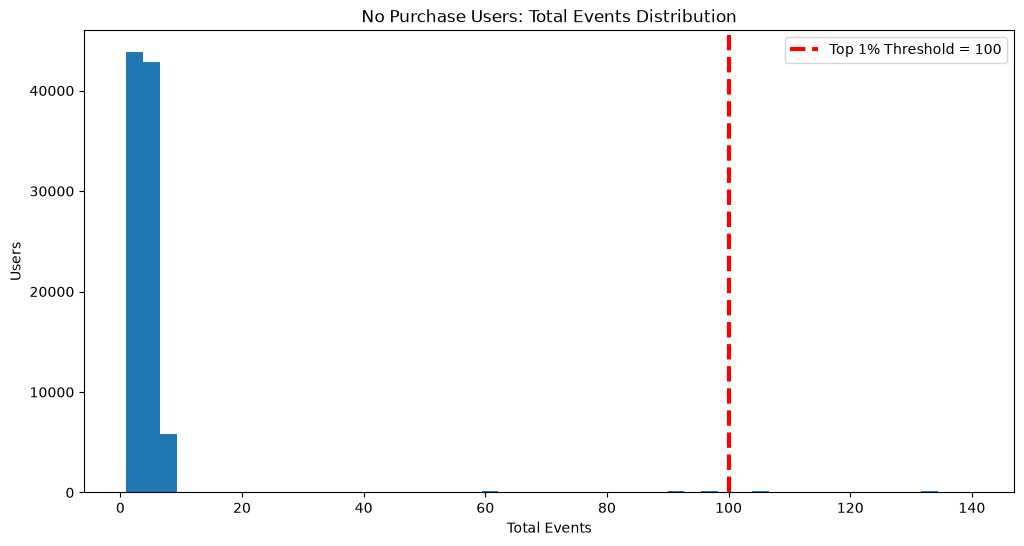

In [8]:
plt.figure(figsize=(12,6))

plt.hist(no_purchase['total_events'],
         bins=50)

plt.axvline(case1_thresh,
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Top 1% Threshold = {case1_thresh:.0f}')

plt.legend()
plt.title('No Purchase Users: Total Events Distribution')
plt.xlabel('Total Events')
plt.ylabel('Users')

plt.show()

In [9]:
# ---------------------------------------------------------
# CASE 2: Extremely High Clicks + No Purchase
# CTR-based: clicks >> impressions, or absolute click count is extreme, with 0 purchases
# ---------------------------------------------------------
no_purchase = no_purchase.copy()
no_purchase['ctr'] = no_purchase['n_clicks'] / no_purchase['n_impressions'].replace(0, np.nan)

click_thresh = no_purchase['n_clicks'].quantile(0.99)
ctr_thresh = no_purchase['ctr'].quantile(0.99)

case2_users = set(no_purchase.loc[
    (no_purchase['n_clicks'] > click_thresh) | (no_purchase['ctr'] > ctr_thresh),
    'User_ID'
])

print(f"Case 2 click threshold: {click_thresh:.1f}, CTR threshold: {ctr_thresh:.2f}")
print(f"Case 2 flagged users: {len(case2_users)}")


Case 2 click threshold: 50.0, CTR threshold: 1.00
Case 2 flagged users: 917


In [10]:
# ---------------------------------------------------------
# CASE 3: Repeated Pattern
# Exact same (Channel, Event_Type) pair repeated many times for one user,
# OR exact same Campaign_ID hit an abnormal number of times
# ---------------------------------------------------------
camp_repeat = touch.groupby(['User_ID', 'Campaign_ID']).size().reset_index(name='hits')
max_camp_repeat = camp_repeat.groupby('User_ID')['hits'].max().reset_index(name='max_campaign_hits')

channel_event_repeat = touch.groupby(['User_ID', 'Channel', 'Event_Type']).size().reset_index(name='hits')
max_ce_repeat = channel_event_repeat.groupby('User_ID')['hits'].max().reset_index(name='max_channel_event_hits')

repeat_feats = max_camp_repeat.merge(max_ce_repeat, on='User_ID')

camp_hits_thresh = repeat_feats['max_campaign_hits'].quantile(0.99)
ce_hits_thresh = repeat_feats['max_channel_event_hits'].quantile(0.99)

case3_users = set(repeat_feats.loc[
    (repeat_feats['max_campaign_hits'] > camp_hits_thresh) |
    (repeat_feats['max_channel_event_hits'] > ce_hits_thresh),
    'User_ID'
])

print(f"Case 3 campaign-hit threshold: {camp_hits_thresh:.1f}, channel-event threshold: {ce_hits_thresh:.1f}")
print(f"Case 3 flagged users: {len(case3_users)}")

Case 3 campaign-hit threshold: 26.0, channel-event threshold: 13.0
Case 3 flagged users: 971


In [11]:
# ---------------------------------------------------------
# CASE 4: Impossible Timing
# Consecutive events (any events, or specifically funnel progressions like
# Impression->Click->Purchase) happening in near-zero / sub-human time gaps
# ---------------------------------------------------------
touch['prev_ts'] = touch.groupby('User_ID')['Timestamp'].shift(1)
touch['gap_sec'] = (touch['Timestamp'] - touch['prev_ts']).dt.total_seconds()

# Flag any gap that is impossibly small (e.g. < 1 second) between distinct logged events
impossible_events = touch[(touch['gap_sec'] >= 0) & (touch['gap_sec'] < 1)]
impossible_counts = impossible_events.groupby('User_ID').size().reset_index(name='n_impossible_gaps')

# Also specifically check full funnel sprints: Impression -> Click -> Purchase all within X seconds
touch['rank'] = touch['Event_Type'].map(funnel_rank)

def fastest_full_funnel_sprint(g):
    g = g.sort_values('Timestamp')
    ts = g['Timestamp'].values
    ranks = g['rank'].values
    min_span = np.inf
    # check rolling windows where rank increases 1->4 monotonically
    start_idx = None
    for i in range(len(ranks)):
        if ranks[i] == 1:
            start_idx = i
        if ranks[i] == 4 and start_idx is not None:
            span = (ts[i] - ts[start_idx]).astype('timedelta64[s]').astype(float)
            if span < min_span:
                min_span = span
    return min_span

funnel_sprint = touch.groupby('User_ID').apply(fastest_full_funnel_sprint).reset_index(name='fastest_funnel_sprint_sec')
funnel_sprint = funnel_sprint[np.isfinite(funnel_sprint['fastest_funnel_sprint_sec'])]

sprint_thresh = 5  # seconds -- impression to purchase in under 5 sec is humanly impossible

case4a_users = set(impossible_counts.loc[impossible_counts['n_impossible_gaps'] >= 3, 'User_ID'])
case4b_users = set(funnel_sprint.loc[funnel_sprint['fastest_funnel_sprint_sec'] < sprint_thresh, 'User_ID'])
case4_users = case4a_users | case4b_users

print(f"Case 4a (sub-1s repeated gaps) flagged: {len(case4a_users)}")
print(f"Case 4b (full funnel sprint < {sprint_thresh}s) flagged: {len(case4b_users)}")
print(f"Case 4 total flagged users: {len(case4_users)}")

# ---------------------------------------------------------
# COMBINE ALL CASES
# ---------------------------------------------------------
all_bot_users = case1_users | case2_users | case3_users | case4_users

print("\n=== SUMMARY ===")
print(f"Case 1 (High touchpoints, no purchase): {len(case1_users)}")
print(f"Case 2 (Extreme clicks, no purchase):    {len(case2_users)}")
print(f"Case 3 (Repeated pattern):               {len(case3_users)}")
print(f"Case 4 (Impossible timing):              {len(case4_users)}")
print(f"Union (any case triggered):              {len(all_bot_users)}")
print(f"Intersection of all 4 cases:             {len(case1_users & case2_users & case3_users & case4_users)}")

# Overlap matrix - see how much cases agree with each other
from itertools import combinations
case_dict = {'Case1': case1_users, 'Case2': case2_users, 'Case3': case3_users, 'Case4': case4_users}
for a, b in combinations(case_dict.keys(), 2):
    print(f"{a} ∩ {b}: {len(case_dict[a] & case_dict[b])}")

Case 4a (sub-1s repeated gaps) flagged: 1965
Case 4b (full funnel sprint < 5s) flagged: 0
Case 4 total flagged users: 1965

=== SUMMARY ===
Case 1 (High touchpoints, no purchase): 917
Case 2 (Extreme clicks, no purchase):    917
Case 3 (Repeated pattern):               971
Case 4 (Impossible timing):              1965
Union (any case triggered):              1965
Intersection of all 4 cases:             820
Case1 ∩ Case2: 917
Case1 ∩ Case3: 820
Case1 ∩ Case4: 917
Case2 ∩ Case3: 820
Case2 ∩ Case4: 917
Case3 ∩ Case4: 971


In [12]:

# ---------------------------------------------------------
# CASE 5: Impossible CTR (clicks > impressions, or CTR == 1.0 / near-1.0 across many events)
# ---------------------------------------------------------
agg['ctr'] = agg['n_clicks'] / agg['n_impressions'].replace(0, np.nan)

# Hard impossibility: more clicks than impressions ever recorded
case5a_users = set(agg.loc[agg['n_clicks'] > agg['n_impressions'], 'User_ID'])

# Statistical impossibility: CTR ~100% with a meaningful sample size (not just 1 imp + 1 click by luck)
case5b_users = set(agg.loc[
    (agg['ctr'] >= 0.95) & (agg['n_impressions'] >= 5), 'User_ID'
])

case5_users = case5a_users | case5b_users
print(f"Case 5a (clicks > impressions): {len(case5a_users)}")
print(f"Case 5b (CTR >= 95% with n_impressions>=5): {len(case5b_users)}")
print(f"Case 5 total (Impossible CTR): {len(case5_users)}")

Case 5a (clicks > impressions): 0
Case 5b (CTR >= 95% with n_impressions>=5): 1952
Case 5 total (Impossible CTR): 1952


In [13]:
# ---------------------------------------------------------
# CASE 7: Identical Time Gaps
# Bots scripted on fixed intervals -> the gap between consecutive events
# is exactly the same (or near-identical) repeatedly for a user
# ---------------------------------------------------------
touch['prev_ts'] = touch.groupby('User_ID')['Timestamp'].shift(1)
touch['gap_sec'] = (touch['Timestamp'] - touch['prev_ts']).dt.total_seconds()

gap_only = touch.dropna(subset=['gap_sec'])

def identical_gap_stats(g):
    gaps = g['gap_sec'].round(0)  # round to nearest second to catch near-identical
    if len(gaps) < 3:
        return pd.Series({'n_gaps': len(gaps), 'most_common_gap_count': 0, 'identical_gap_ratio': 0.0})
    counts = gaps.value_counts()
    top_count = counts.iloc[0]
    return pd.Series({
        'n_gaps': len(gaps),
        'most_common_gap_count': top_count,
        'identical_gap_ratio': top_count / len(gaps)
    })

gap_stats = gap_only.groupby('User_ID').apply(identical_gap_stats).reset_index()

# Flag: at least 3 identical repeats of the same gap AND it covers a high share of all gaps for that user
identical_ratio_thresh = 0.6   # 60%+ of a user's gaps are the exact same value -> scripted behavior
case7_users = set(gap_stats.loc[
    (gap_stats['most_common_gap_count'] >= 3) & (gap_stats['identical_gap_ratio'] >= identical_ratio_thresh),
    'User_ID'
])

print(f"\nCase 7 (Identical Time Gaps) flagged: {len(case7_users)}")


Case 7 (Identical Time Gaps) flagged: 59


In [14]:

# ---------------------------------------------------------
# CASE 8: Too Many Channels in One Journey (excessive channel-hopping / repetition)
# A real user journey rarely touches all 5 channels repeatedly within a short journey;
# flag users who touch an excessive number of DISTINCT channels, or
# touch channels with abnormally high total channel-switch count
# ---------------------------------------------------------
channel_feats = touch.groupby('User_ID').agg(
    n_distinct_channels=('Channel', 'nunique'),
    n_total_touches=('Channel', 'count')
).reset_index()

# Channel switch count: how many times consecutive events differ in channel
touch['prev_channel'] = touch.groupby('User_ID')['Channel'].shift(1)
touch['channel_switch'] = (touch['Channel'] != touch['prev_channel']).astype(int)
# first event per user isn't a real "switch" -- correct for it
first_event_idx = touch.groupby('User_ID').head(1).index
touch.loc[first_event_idx, 'channel_switch'] = 0

switch_feats = touch.groupby('User_ID')['channel_switch'].sum().reset_index(name='n_channel_switches')
channel_feats = channel_feats.merge(switch_feats, on='User_ID')

In [15]:

# All 5 channels touched AND excessive switching relative to total touches
all_channels_touched = touch['Channel'].nunique()  # should be 5
switch_ratio_thresh = channel_feats['n_channel_switches'].div(channel_feats['n_total_touches']).quantile(0.99)
channel_feats['switch_ratio'] = channel_feats['n_channel_switches'] / channel_feats['n_total_touches']

case8_users = set(channel_feats.loc[
    (channel_feats['n_distinct_channels'] >= all_channels_touched) &
    (channel_feats['switch_ratio'] > switch_ratio_thresh),
    'User_ID'
])

print(f"\nCase 8 (Too many channels / excessive hopping) flagged: {len(case8_users)}")



Case 8 (Too many channels / excessive hopping) flagged: 50


In [16]:

# ---------------------------------------------------------
# COMBINE WITH PREVIOUS CASES (case1-4 assumed already computed in session)
# ---------------------------------------------------------
all_new_bot_users = case5_users | case7_users | case8_users

print("\n=== NEW CASES SUMMARY ===")
print(f"Case 5 (Impossible CTR):        {len(case5_users)}")
print(f"Case 7 (Identical Time Gaps):    {len(case7_users)}")
print(f"Case 8 (Too Many Channels):      {len(case8_users)}")
print(f"Union of new cases:              {len(all_new_bot_users)}")

# Overlap with earlier cases (run only if case1_users..case4_users exist in your session)
try:
    grand_union = case1_users | case2_users | case3_users | case4_users | all_new_bot_users
    print(f"\nGrand union (all 8 cases combined): {len(grand_union)}")
except NameError:
    print("\n(Case 1-4 variables not found in this session -- run earlier cell first to combine)")


=== NEW CASES SUMMARY ===
Case 5 (Impossible CTR):        1952
Case 7 (Identical Time Gaps):    59
Case 8 (Too Many Channels):      50
Union of new cases:              2061

Grand union (all 8 cases combined): 2074


## 2. Bot confirmation

In [17]:
import pandas as pd
import numpy as np
from itertools import combinations

# ---------------------------------------------------------
# 0. SAFETY CHECK -- confirm all 8 case sets exist
# ---------------------------------------------------------
case_dict = {
    'Case1_HighTouch_NoPurchase': case1_users,
    'Case2_HighClicks_NoPurchase': case2_users,
    'Case3_RepeatedPattern': case3_users,
    'Case4_ImpossibleTiming': case4_users,
    'Case5_ImpossibleCTR': case5_users,
    'Case7_IdenticalTimeGaps': case7_users,
    'Case8_TooManyChannels': case8_users,
}

for name, s in case_dict.items():
    print(f"{name}: {len(s)} users")

Case1_HighTouch_NoPurchase: 917 users
Case2_HighClicks_NoPurchase: 917 users
Case3_RepeatedPattern: 971 users
Case4_ImpossibleTiming: 1965 users
Case5_ImpossibleCTR: 1952 users
Case7_IdenticalTimeGaps: 59 users
Case8_TooManyChannels: 50 users



--- Pairwise Overlap Matrix (counts) ---
                             Case1_HighTouch_NoPurchase  \
Case1_HighTouch_NoPurchase                        917.0   
Case2_HighClicks_NoPurchase                       917.0   
Case3_RepeatedPattern                             820.0   
Case4_ImpossibleTiming                            917.0   
Case5_ImpossibleCTR                               917.0   
Case7_IdenticalTimeGaps                             0.0   
Case8_TooManyChannels                               0.0   

                             Case2_HighClicks_NoPurchase  \
Case1_HighTouch_NoPurchase                         917.0   
Case2_HighClicks_NoPurchase                        917.0   
Case3_RepeatedPattern                              820.0   
Case4_ImpossibleTiming                             917.0   
Case5_ImpossibleCTR                                917.0   
Case7_IdenticalTimeGaps                              0.0   
Case8_TooManyChannels                                0.0   

    

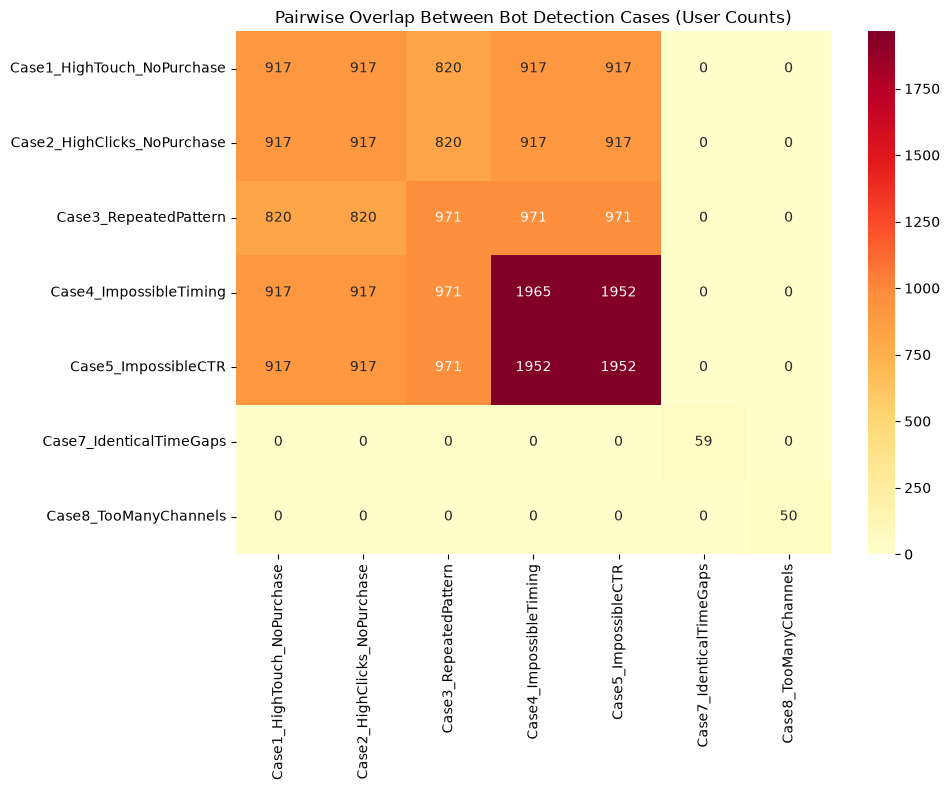

In [18]:
# ---------------------------------------------------------
# 1. PAIRWISE OVERLAP MATRIX (counts)
# ---------------------------------------------------------
case_names = list(case_dict.keys())
overlap_matrix = pd.DataFrame(index=case_names, columns=case_names, dtype=int)

for a in case_names:
    for b in case_names:
        overlap_matrix.loc[a, b] = len(case_dict[a] & case_dict[b])

print("\n--- Pairwise Overlap Matrix (counts) ---")
print(overlap_matrix)

# Heatmap visualization
import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overlap_matrix.astype(int), annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title("Pairwise Overlap Between Bot Detection Cases (User Counts)")
plt.tight_layout()
plt.savefig('case_overlap_heatmap.png', dpi=150)
plt.show()


In [19]:
# ---------------------------------------------------------
# 2. PAIRWISE OVERLAP AS % OF SMALLER CASE (normalized -- shows redundancy)
# ---------------------------------------------------------
overlap_pct_matrix = pd.DataFrame(index=case_names, columns=case_names, dtype=float)
for a in case_names:
    for b in case_names:
        denom = min(len(case_dict[a]), len(case_dict[b]))
        overlap_pct_matrix.loc[a, b] = (len(case_dict[a] & case_dict[b]) / denom * 100) if denom > 0 else 0

print("\n--- Pairwise Overlap Matrix (% of smaller set) ---")
print(overlap_pct_matrix.round(1))


--- Pairwise Overlap Matrix (% of smaller set) ---
                             Case1_HighTouch_NoPurchase  \
Case1_HighTouch_NoPurchase                        100.0   
Case2_HighClicks_NoPurchase                       100.0   
Case3_RepeatedPattern                              89.4   
Case4_ImpossibleTiming                            100.0   
Case5_ImpossibleCTR                               100.0   
Case7_IdenticalTimeGaps                             0.0   
Case8_TooManyChannels                               0.0   

                             Case2_HighClicks_NoPurchase  \
Case1_HighTouch_NoPurchase                         100.0   
Case2_HighClicks_NoPurchase                        100.0   
Case3_RepeatedPattern                               89.4   
Case4_ImpossibleTiming                             100.0   
Case5_ImpossibleCTR                                100.0   
Case7_IdenticalTimeGaps                              0.0   
Case8_TooManyChannels                                0.


--- Distribution of How Many Cases Each Flagged User Trips ---
1    122
2    884
3    151
4     97
5    820
Name: count, dtype: int64

Total distinct users flagged by AT LEAST 1 case: 2074


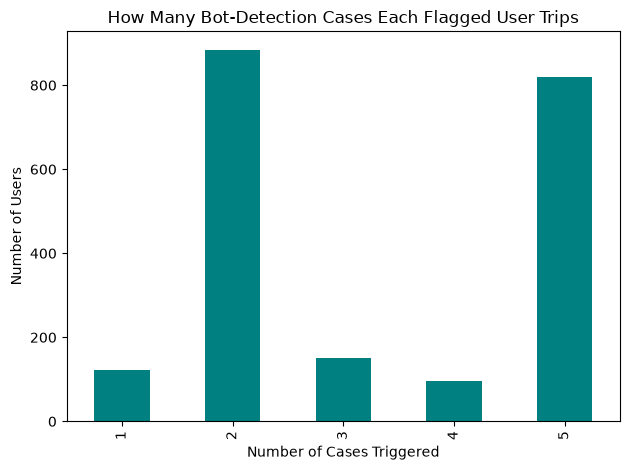

In [20]:
# ---------------------------------------------------------
# 3. PER-USER VOTE COUNT -- how many of the 8 cases each flagged user trips
# ---------------------------------------------------------
all_flagged_users = set().union(*case_dict.values())
vote_counts = pd.Series(0, index=list(all_flagged_users), dtype=int)

for s in case_dict.values():
    for u in s:
        vote_counts[u] += 1

vote_dist = vote_counts.value_counts().sort_index()
print("\n--- Distribution of How Many Cases Each Flagged User Trips ---")
print(vote_dist)
print(f"\nTotal distinct users flagged by AT LEAST 1 case: {len(all_flagged_users)}")

fig, ax = plt.subplots()
vote_dist.plot(kind='bar', color='teal', ax=ax)
ax.set_xlabel("Number of Cases Triggered")
ax.set_ylabel("Number of Users")
ax.set_title("How Many Bot-Detection Cases Each Flagged User Trips")
plt.tight_layout()
plt.savefig('vote_distribution.png', dpi=150)
plt.show()



In [21]:
# ---------------------------------------------------------
# 4. CHECK FINAL BOT COUNT UNDER DIFFERENT VOTING THRESHOLDS
# ---------------------------------------------------------
for min_votes in range(1, 6):
    n_users = (vote_counts >= min_votes).sum()
    print(f"Users flagged by >= {min_votes} case(s): {n_users}")


Users flagged by >= 1 case(s): 2074
Users flagged by >= 2 case(s): 1952
Users flagged by >= 3 case(s): 1068
Users flagged by >= 4 case(s): 917
Users flagged by >= 5 case(s): 820


In [22]:

# ---------------------------------------------------------
# 5. EXACT UNION / INTERSECTION CHECKS
# ---------------------------------------------------------
union_all = set().union(*case_dict.values())
intersection_all = set.intersection(*case_dict.values()) if all(len(s) > 0 for s in case_dict.values()) else set()

print(f"\nUnion of all 8 cases:         {len(union_all)}")
print(f"Intersection of all 8 cases:  {len(intersection_all)}")


Union of all 8 cases:         2074
Intersection of all 8 cases:  0


In [23]:

# ---------------------------------------------------------
# 6. SPECIFICALLY CHECK AGAINST YOUR SUSPECTED 1952
# ---------------------------------------------------------
target = 1952
print(f"\n--- Checking which voting threshold lands closest to {target} ---")
for min_votes in range(1, 6):
    n_users = (vote_counts >= min_votes).sum()
    diff = n_users - target
    print(f"min_votes={min_votes}: {n_users} users (diff from target: {diff:+d})")

# Also check pure union vs target directly
print(f"\nPure union count: {len(union_all)} vs target {target} -> diff {len(union_all) - target:+d}")



--- Checking which voting threshold lands closest to 1952 ---
min_votes=1: 2074 users (diff from target: +122)
min_votes=2: 1952 users (diff from target: +0)
min_votes=3: 1068 users (diff from target: -884)
min_votes=4: 917 users (diff from target: -1035)
min_votes=5: 820 users (diff from target: -1132)

Pure union count: 2074 vs target 1952 -> diff +122


In [24]:

# ---------------------------------------------------------
# 7. UNIQUE-TO-EACH-CASE COUNT (users flagged by ONLY that one case, no others)
# ---------------------------------------------------------
print("\n--- Users Flagged Uniquely by Only ONE Case ---")
for name, s in case_dict.items():
    others = set().union(*[v for k, v in case_dict.items() if k != name])
    unique_to_this = s - others
    print(f"{name}: {len(unique_to_this)} users flagged ONLY by this case")


--- Users Flagged Uniquely by Only ONE Case ---
Case1_HighTouch_NoPurchase: 0 users flagged ONLY by this case
Case2_HighClicks_NoPurchase: 0 users flagged ONLY by this case
Case3_RepeatedPattern: 0 users flagged ONLY by this case
Case4_ImpossibleTiming: 13 users flagged ONLY by this case
Case5_ImpossibleCTR: 0 users flagged ONLY by this case
Case7_IdenticalTimeGaps: 59 users flagged ONLY by this case
Case8_TooManyChannels: 50 users flagged ONLY by this case


## 3. Bot Removal

In [25]:
# ==========================================
# FINAL BOT USERS
# ==========================================

all_bot_users = (
    case1_users |
    case2_users |
    case3_users |
    case4_users |
    case5_users |
    case7_users |
    case8_users
)

print("Total Suspicious Users:", len(all_bot_users))

Total Suspicious Users: 2074


In [26]:
# ==========================================
# USER LEVEL BOT REPORT
# ==========================================

bot_report = pd.DataFrame({
    'User_ID': list(all_bot_users)
})

bot_report['Case1_HighTouch_NoPurchase'] = bot_report['User_ID'].isin(case1_users)
bot_report['Case2_ExtremeClicks'] = bot_report['User_ID'].isin(case2_users)
bot_report['Case3_RepeatedPattern'] = bot_report['User_ID'].isin(case3_users)
bot_report['Case4_ImpossibleTiming'] = bot_report['User_ID'].isin(case4_users)
bot_report['Case5_ImpossibleCTR'] = bot_report['User_ID'].isin(case5_users)
bot_report['Case7_IdenticalTimeGaps'] = bot_report['User_ID'].isin(case7_users)
bot_report['Case8_ChannelHopping'] = bot_report['User_ID'].isin(case8_users)

bot_report['Total_Flags'] = (
    bot_report.iloc[:,1:]
    .sum(axis=1)
)

bot_report.head()

,User_ID,Case1_HighTouch_NoPurchase,Case2_ExtremeClicks,Case3_RepeatedPattern,Case4_ImpossibleTiming,Case5_ImpossibleCTR,Case7_IdenticalTimeGaps,Case8_ChannelHopping,Total_Flags
0,U_B09_07141,False,False,False,True,True,False,False,2
1,U_B09_01529,True,True,True,True,True,False,False,5
2,U_B01_04052,True,True,True,True,True,False,False,5
3,U_B06_06734,True,True,True,True,True,False,False,5
4,U_B05_01511,False,False,False,True,True,False,False,2


In [27]:
bot_report.to_csv(
    'suspicious_users_report.csv',
    index=False
)

print("Saved suspicious_users_report.csv")

Saved suspicious_users_report.csv


In [28]:
# ==========================================
# CLEAN TOUCHPOINTS
# ==========================================

touch_clean = touch[
    ~touch['User_ID'].isin(all_bot_users)
].copy()

print("Original Events :", len(touch))
print("Clean Events    :", len(touch_clean))
print("Removed Events  :", len(touch)-len(touch_clean))

Original Events : 566510
Clean Events    : 371786
Removed Events  : 194724


In [29]:
# ==========================================
# CLEAN USER PROFILES
# ==========================================

clean_profiles = profiles[
    ~profiles['User_ID'].isin(all_bot_users)
].copy()

print("Original Users :", profiles['User_ID'].nunique())
print("Clean Users    :", clean_profiles['User_ID'].nunique())

Original Users : 100000
Clean Users    : 97926


In [30]:
touch_clean.to_csv(
    'touchpoints_cleaned.csv',
    index=False
)

clean_profiles.to_csv(
    'user_profiles_cleaned.csv',
    index=False
)

print("Files Saved Successfully")

Files Saved Successfully


## 4. Journey Analysis

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# ---------------------------------------------------------
# 0. LOAD CLEANED (BOT-FILTERED) DATA
# ---------------------------------------------------------
# touch_clean should already exist from Phase 1A (bot removal). If reloading fresh:
# touch_clean = pd.read_csv('/mnt/user-data/outputs/touchpoints_clean.csv')
# touch_clean['Timestamp'] = pd.to_datetime(touch_clean['Timestamp'])

touch_clean['Brand_ID'] = touch_clean['User_ID'].str.extract(r'U_(B\d+)_')
touch_clean = touch_clean.sort_values(['User_ID', 'Timestamp']).reset_index(drop=True)

print("Brands found:", sorted(touch_clean['Brand_ID'].unique()))
print("Total cleaned events:", len(touch_clean))
print("Total cleaned users:", touch_clean['User_ID'].nunique())


Brands found: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10']
Total cleaned events: 371786
Total cleaned users: 97926


In [32]:

# ---------------------------------------------------------
# 1. JOURNEY CONSTRUCTION
#    Each user's entire event history = one journey (quarter-long window).
#    Collapse consecutive repeats of the same channel into one node.
# ---------------------------------------------------------
def build_path(group):
    group = group.sort_values('Timestamp')
    channels = group['Channel'].tolist()
    # collapse consecutive duplicates
    collapsed = [channels[0]]
    for ch in channels[1:]:
        if ch != collapsed[-1]:
            collapsed.append(ch)
    converted = (group['Event_Type'] == 'Purchase').any()
    return pd.Series({
        'path': collapsed,
        'path_str': ' -> '.join(collapsed),
        'path_length': len(collapsed),
        'raw_touch_count': len(group),
        'converted': converted,
        'brand': group['Brand_ID'].iloc[0]
    })

journeys = touch_clean.groupby('User_ID').apply(build_path).reset_index()
print("\nSample journeys:")
print(journeys[['User_ID','brand','path_str','converted']].head(10))

journeys.to_csv('journeys.csv', index=False)



Sample journeys:
       User_ID brand                                           path_str  \
0  U_B01_00000   B01                                    Influencer Blog   
1  U_B01_00001   B01  Google Search -> Marketplace -> Instagram -> I...   
2  U_B01_00002   B01  Marketplace -> Google Search -> YouTube -> Inf...   
3  U_B01_00003   B01                         Google Search -> Instagram   
4  U_B01_00004   B01                           Google Search -> YouTube   
5  U_B01_00005   B01  Marketplace -> Influencer Blog -> Marketplace ...   
6  U_B01_00006   B01  Google Search -> YouTube -> Influencer Blog ->...   
7  U_B01_00007   B01  Influencer Blog -> YouTube -> Google Search ->...   
8  U_B01_00008   B01                                      Google Search   
9  U_B01_00009   B01  Influencer Blog -> YouTube -> Google Search ->...   

   converted  
0      False  
1      False  
2      False  
3      False  
4      False  
5      False  
6      False  
7      False  
8      False  
9     


--- Overall Funnel (users reaching each stage) ---
Impression     97926
Click          23440
Add-to-Cart     8325
Purchase        5445
dtype: int64

--- Per-Brand Funnel ---
          Impression  Click  Add-to-Cart  Purchase
Brand_ID                                          
B01             9788   2479          995       693
B02             9777   2816         1501      1251
B03             9816   2143          591       303
B04             9809   2176          624       315
B05             9776   2042          454       160
B06             9788   2170          573       290
B07             9778   3122         1888      1616
B08             9801   2131          608       305
B09             9792   2123          498       205
B10             9801   2238          593       307


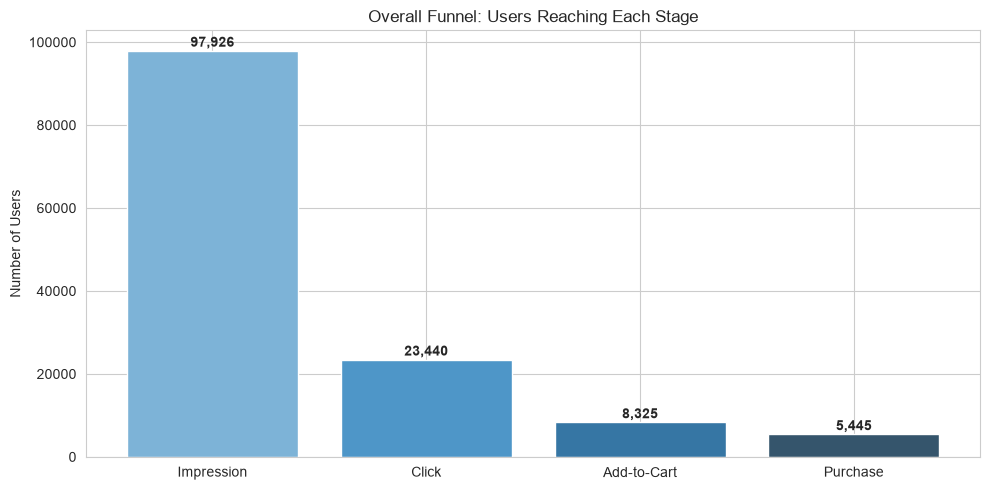

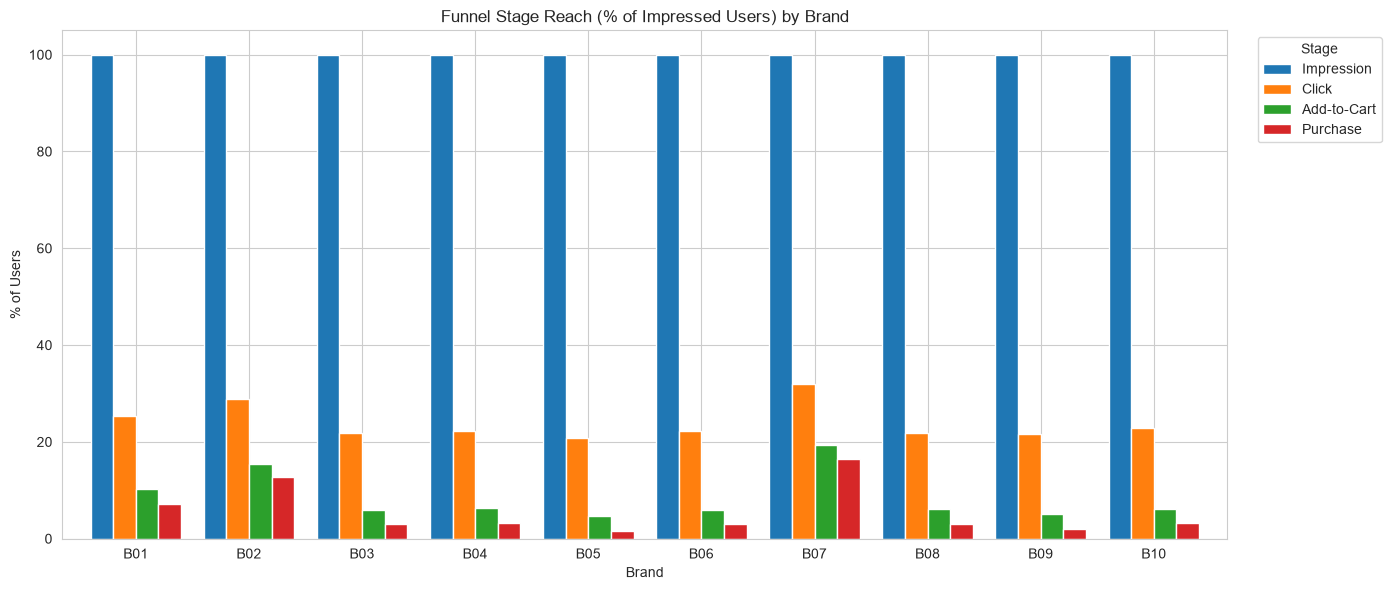

In [33]:
# ---------------------------------------------------------
# 2. FUNNEL ANALYSIS (overall + per brand)
#    Funnel stages: Impression -> Click -> Add-to-Cart -> Purchase
#    A user "reaches" a stage if they have at least one event of that type or beyond.
# ---------------------------------------------------------
funnel_rank = {'Impression': 1, 'Click': 2, 'Add-to-Cart': 3, 'Purchase': 4}
touch_clean['rank'] = touch_clean['Event_Type'].map(funnel_rank)

user_max_rank = touch_clean.groupby(['User_ID', 'Brand_ID'])['rank'].max().reset_index()

def funnel_counts(df):
    return pd.Series({
        'Impression': (df['rank'] >= 1).sum(),
        'Click': (df['rank'] >= 2).sum(),
        'Add-to-Cart': (df['rank'] >= 3).sum(),
        'Purchase': (df['rank'] >= 4).sum(),
    })

overall_funnel = funnel_counts(user_max_rank)
brand_funnel = user_max_rank.groupby('Brand_ID').apply(funnel_counts)

print("\n--- Overall Funnel (users reaching each stage) ---")
print(overall_funnel)
print("\n--- Per-Brand Funnel ---")
print(brand_funnel)

# Visualization: Overall funnel
fig, ax = plt.subplots()
stages = ['Impression', 'Click', 'Add-to-Cart', 'Purchase']
values = [overall_funnel[s] for s in stages]
ax.bar(stages, values, color=sns.color_palette("Blues_d", 4))
for i, v in enumerate(values):
    ax.text(i, v + max(values)*0.01, f"{v:,}", ha='center', fontweight='bold')
ax.set_title("Overall Funnel: Users Reaching Each Stage")
ax.set_ylabel("Number of Users")
plt.tight_layout()
plt.savefig('overall_funnel.png', dpi=150)
plt.show()

# Visualization: Per-brand funnel (grouped bar)
brand_funnel_pct = brand_funnel.div(brand_funnel['Impression'], axis=0) * 100
fig, ax = plt.subplots(figsize=(14, 6))
brand_funnel_pct[stages].plot(kind='bar', ax=ax, width=0.8)
ax.set_title("Funnel Stage Reach (% of Impressed Users) by Brand")
ax.set_ylabel("% of Users")
ax.set_xlabel("Brand")
ax.legend(title='Stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('brand_funnel_pct.png', dpi=150)
plt.show()




Overall Conversion Rate: 5.56%

--- Conversion Rate by Brand ---
brand
B07    16.526897
B02    12.795336
B01     7.080098
B04     3.211337
B10     3.132333
B08     3.111927
B03     3.086797
B06     2.962812
B09     2.093546
B05     1.636661
Name: converted, dtype: float64


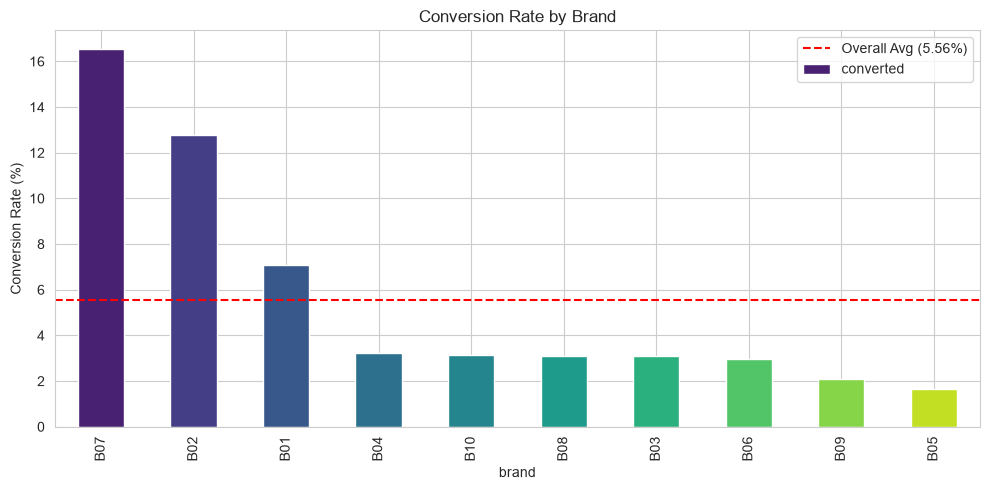

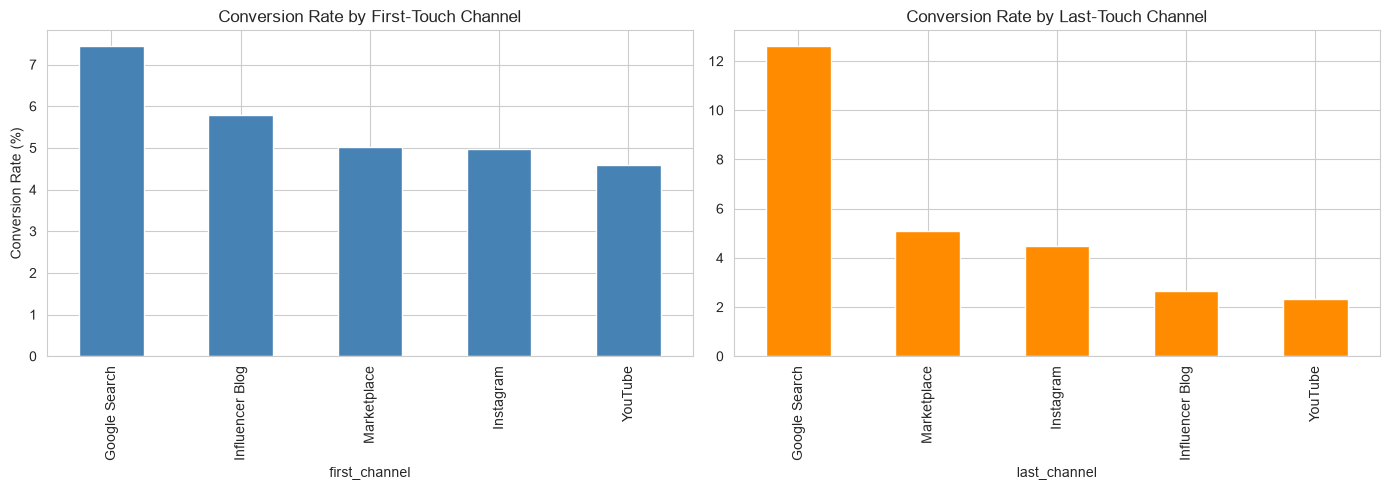

In [34]:

# ---------------------------------------------------------
# 3. CONVERSION RATES (overall + per brand + per channel as first/last touch)
# ---------------------------------------------------------
overall_cvr = journeys['converted'].mean() * 100
print(f"\nOverall Conversion Rate: {overall_cvr:.2f}%")

brand_cvr = journeys.groupby('brand')['converted'].mean().mul(100).sort_values(ascending=False)
print("\n--- Conversion Rate by Brand ---")
print(brand_cvr)

fig, ax = plt.subplots()
brand_cvr.plot(kind='bar', color=sns.color_palette("viridis", len(brand_cvr)), ax=ax)
ax.set_title("Conversion Rate by Brand")
ax.set_ylabel("Conversion Rate (%)")
ax.axhline(overall_cvr, color='red', linestyle='--', label=f'Overall Avg ({overall_cvr:.2f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('brand_conversion_rate.png', dpi=150)
plt.show()

# Conversion rate by entry (first-touch) channel
journeys['first_channel'] = journeys['path'].apply(lambda x: x[0])
journeys['last_channel'] = journeys['path'].apply(lambda x: x[-1])

first_touch_cvr = journeys.groupby('first_channel')['converted'].mean().mul(100).sort_values(ascending=False)
last_touch_cvr = journeys.groupby('last_channel')['converted'].mean().mul(100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
first_touch_cvr.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Conversion Rate by First-Touch Channel")
axes[0].set_ylabel("Conversion Rate (%)")
last_touch_cvr.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title("Conversion Rate by Last-Touch Channel")
plt.tight_layout()
plt.savefig('first_last_touch_cvr.png', dpi=150)
plt.show()



--- Overall Drop-off Table ---
         stage  count  conversion_from_prev  dropoff_from_prev
0   Impression  97926            100.000000           0.000000
1        Click  23440             23.936442          76.063558
2  Add-to-Cart   8325             35.516212          64.483788
3     Purchase   5445             65.405405          34.594595


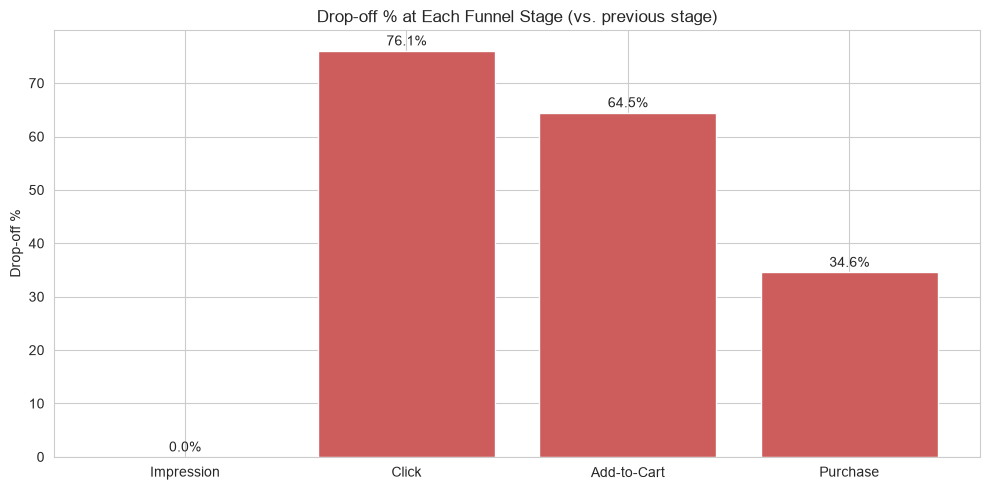


--- Drop-off % by Brand and Stage ---
stage  Impression      Click  Add-to-Cart   Purchase
brand                                               
B01           0.0  74.673069    59.862848  30.351759
B02           0.0  71.197709    46.697443  16.655563
B03           0.0  78.168297    72.421839  48.730964
B04           0.0  77.816291    71.323529  49.519231
B05           0.0  79.112111    77.766895  64.757709
B06           0.0  77.829996    73.594470  49.389180
B07           0.0  68.071180    39.525945  14.406780
B08           0.0  78.257321    71.468794  49.835526
B09           0.0  78.319036    76.542628  58.835341
B10           0.0  77.165595    73.503128  48.229342


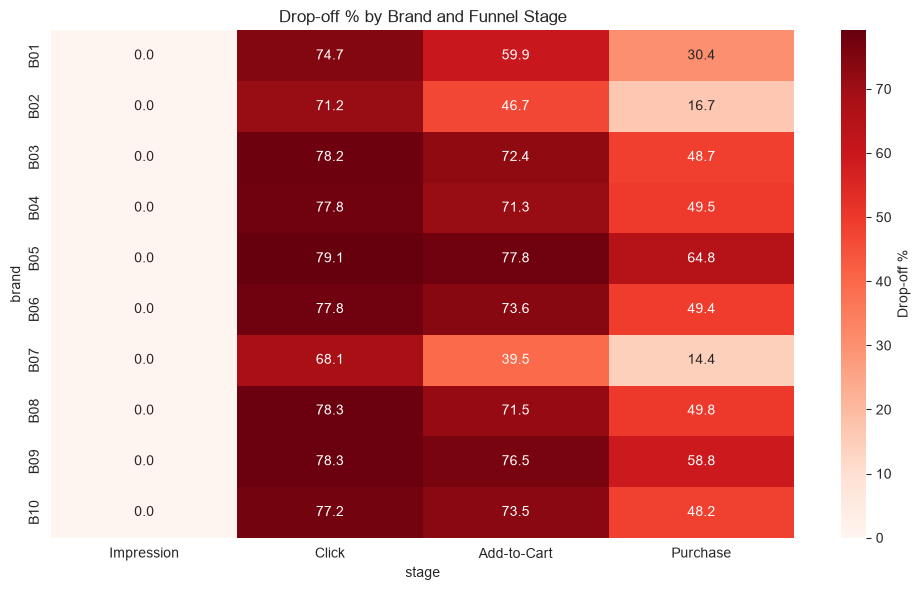

In [35]:

# ---------------------------------------------------------
# 4. DROP-OFF ANALYSIS (overall + per brand)
#    Drop-off % at each funnel transition
# ---------------------------------------------------------
def compute_dropoffs(funnel_series):
    df = pd.DataFrame({'stage': stages, 'count': [funnel_series[s] for s in stages]})
    df['conversion_from_prev'] = df['count'] / df['count'].shift(1) * 100
    df['dropoff_from_prev'] = 100 - df['conversion_from_prev']
    df.loc[0, ['conversion_from_prev', 'dropoff_from_prev']] = [100.0, 0.0]
    return df

overall_dropoff = compute_dropoffs(overall_funnel)
print("\n--- Overall Drop-off Table ---")
print(overall_dropoff)

fig, ax = plt.subplots()
ax.bar(overall_dropoff['stage'], overall_dropoff['dropoff_from_prev'], color='indianred')
for i, v in enumerate(overall_dropoff['dropoff_from_prev']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')
ax.set_title("Drop-off % at Each Funnel Stage (vs. previous stage)")
ax.set_ylabel("Drop-off %")
plt.tight_layout()
plt.savefig('overall_dropoff.png', dpi=150)
plt.show()

# Per-brand drop-off heatmap
brand_dropoff_list = []
for b in sorted(brand_funnel.index):
    d = compute_dropoffs(brand_funnel.loc[b])
    d['brand'] = b
    brand_dropoff_list.append(d)
brand_dropoff_df = pd.concat(brand_dropoff_list)

pivot_dropoff = brand_dropoff_df.pivot(index='brand', columns='stage', values='dropoff_from_prev')[stages]
print("\n--- Drop-off % by Brand and Stage ---")
print(pivot_dropoff)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_dropoff, annot=True, fmt=".1f", cmap="Reds", ax=ax, cbar_kws={'label': 'Drop-off %'})
ax.set_title("Drop-off % by Brand and Funnel Stage")
plt.tight_layout()
plt.savefig('brand_dropoff_heatmap.png', dpi=150)
plt.show()

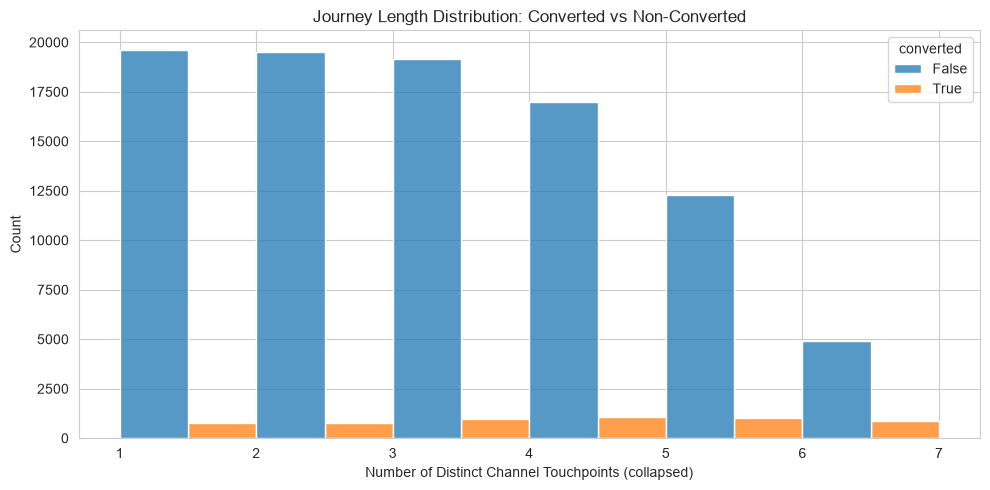


--- Avg Journey Length: Converted vs Not ---
converted
False    2.973357
True     3.680808
Name: path_length, dtype: float64

--- Top 10 Converting Paths (Overall) ---
path_str
Google Search                                        231
Instagram                                            140
Marketplace                                          138
Influencer Blog                                      133
Influencer Blog -> Google Search                     109
Google Search -> Influencer Blog -> Google Search    107
YouTube                                              105
YouTube -> Google Search                              67
Google Search -> Instagram -> Google Search           59
Instagram -> Google Search                            53
Name: count, dtype: int64

--- Top 10 Converting Paths for B01 ---
path_str
Instagram                                    45
Instagram -> YouTube -> Instagram            17
Google Search                                13
Influencer Blog                 

In [36]:


# ---------------------------------------------------------
# 5. JOURNEY LENGTH / COMPLEXITY ANALYSIS
# ---------------------------------------------------------
fig, ax = plt.subplots()
sns.histplot(data=journeys, x='path_length', hue='converted', bins=range(1,8), multiple='dodge', ax=ax)
ax.set_title("Journey Length Distribution: Converted vs Non-Converted")
ax.set_xlabel("Number of Distinct Channel Touchpoints (collapsed)")
plt.tight_layout()
plt.savefig('journey_length_dist.png', dpi=150)
plt.show()

avg_path_len_by_conv = journeys.groupby('converted')['path_length'].mean()
print("\n--- Avg Journey Length: Converted vs Not ---")
print(avg_path_len_by_conv)

# Most common converting paths (top 10) -- overall and example brand
top_paths_overall = journeys[journeys['converted']]['path_str'].value_counts().head(10)
print("\n--- Top 10 Converting Paths (Overall) ---")
print(top_paths_overall)

example_brand = 'B01'
top_paths_brand = journeys[(journeys['converted']) & (journeys['brand']==example_brand)]['path_str'].value_counts().head(10)
print(f"\n--- Top 10 Converting Paths for {example_brand} ---")
print(top_paths_brand)

example_brand = 'B02'
top_paths_brand = journeys[(journeys['converted']) & (journeys['brand']==example_brand)]['path_str'].value_counts().head(10)
print(f"\n--- Top 10 Converting Paths for {example_brand} ---")
print(top_paths_brand)

In [37]:

# ---------------------------------------------------------
# 6. OVERALL SUMMARY OF THIS STEP
# ---------------------------------------------------------
summary = pd.DataFrame({
    'Metric': [
        'Total Cleaned Users',
        'Total Cleaned Events',
        'Total Journeys Built',
        'Overall Conversion Rate (%)',
        'Avg Journey Length (Converted)',
        'Avg Journey Length (Non-Converted)',
        'Highest Converting Brand',
        'Lowest Converting Brand',
        'Highest Drop-off Stage (Overall)',
    ],
    'Value': [
        touch_clean['User_ID'].nunique(),
        len(touch_clean),
        len(journeys),
        round(overall_cvr, 2),
        round(avg_path_len_by_conv.get(True, np.nan), 2),
        round(avg_path_len_by_conv.get(False, np.nan), 2),
        brand_cvr.idxmax(),
        brand_cvr.idxmin(),
        overall_dropoff.loc[overall_dropoff['dropoff_from_prev'].idxmax(), 'stage'],
    ]
})

print("\n" + "="*50)
print("PHASE 1B SUMMARY: SESSION/JOURNEY CONSTRUCTION & FUNNEL ANALYSIS")
print("="*50)
print(summary.to_string(index=False))

#summary.to_csv('/mnt/user-data/outputs/phase1b_summary.csv', index=False)
#journeys.to_csv('/mnt/user-data/outputs/journeys_final.csv', index=False)


PHASE 1B SUMMARY: SESSION/JOURNEY CONSTRUCTION & FUNNEL ANALYSIS
                            Metric  Value
               Total Cleaned Users  97926
              Total Cleaned Events 371786
              Total Journeys Built  97926
       Overall Conversion Rate (%)   5.56
    Avg Journey Length (Converted)   3.68
Avg Journey Length (Non-Converted)   2.97
          Highest Converting Brand    B07
           Lowest Converting Brand    B05
  Highest Drop-off Stage (Overall)  Click


## 4. Markov Analysis

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# ---------------------------------------------------------
# 0. PREP -- using existing journeys dataframe (User_ID, brand, path, path_str, converted)
# ---------------------------------------------------------
print("Total journeys:", len(journeys))
print("Brands:", sorted(journeys['brand'].unique()))
print("Overall conversion rate:", journeys['converted'].mean()*100, "%")

ALL_CHANNELS = sorted(touch_clean['Channel'].unique())
print("Channels:", ALL_CHANNELS)

START = 'Start'
CONV = 'Conversion'
NULL = 'Null'

Total journeys: 97926
Brands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10']
Overall conversion rate: 5.560321058758654 %
Channels: ['Google Search', 'Influencer Blog', 'Instagram', 'Marketplace', 'YouTube']


In [39]:

# ---------------------------------------------------------
# 1. BUILD FULL MARKOV PATHS (Start -> channels -> Conversion/Null)
# ---------------------------------------------------------
def make_markov_path(row):
    path = [START] + row['path']
    path.append(CONV if row['converted'] else NULL)
    return path

journeys['markov_path'] = journeys.apply(make_markov_path, axis=1)

In [40]:

# ---------------------------------------------------------
# 2. TRANSITION MATRIX BUILDER (reusable for overall + per brand)
# ---------------------------------------------------------
def build_transition_matrix(paths):
    states = set([START, CONV, NULL])
    for p in paths:
        states.update(p)
    states = sorted(states)

    trans_counts = pd.DataFrame(0, index=states, columns=states, dtype=float)
    for p in paths:
        for i in range(len(p) - 1):
            trans_counts.loc[p[i], p[i+1]] += 1

    # Normalize rows to probabilities; absorbing states stay at 0 outflow
    trans_probs = trans_counts.div(trans_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    trans_probs.loc[CONV, CONV] = 1.0
    trans_probs.loc[NULL, NULL] = 1.0
    return trans_probs


In [41]:

# ---------------------------------------------------------
# 3. CONVERSION PROBABILITY VIA ABSORPTION (matrix-based, exact)
# ---------------------------------------------------------
def compute_conversion_prob(trans_probs, start_state=START):
    states = trans_probs.index.tolist()
    transient = [s for s in states if s not in (CONV, NULL)]
    absorbing = [CONV, NULL]

    Q = trans_probs.loc[transient, transient].values
    R = trans_probs.loc[transient, absorbing].values

    I = np.eye(len(transient))
    try:
        N = np.linalg.inv(I - Q)   # fundamental matrix
    except np.linalg.LinAlgError:
        N = np.linalg.pinv(I - Q)

    B = N @ R   # absorption probabilities from each transient state
    B_df = pd.DataFrame(B, index=transient, columns=absorbing)

    return B_df.loc[start_state, CONV]


In [42]:
# ---------------------------------------------------------
# 4. REMOVAL EFFECT CALCULATION (the actual attribution engine)
# ---------------------------------------------------------
def compute_removal_effects(paths, channels):
    trans_probs = build_transition_matrix(paths)
    baseline_cvr = compute_conversion_prob(trans_probs)

    removal_effects = {}
    for ch in channels:
        if ch not in trans_probs.index:
            removal_effects[ch] = 0.0
            continue
        modified = trans_probs.copy()
        # redirect all outflow from this channel straight to Null
        modified.loc[ch, :] = 0.0
        modified.loc[ch, NULL] = 1.0
        # also remove inbound transitions INTO this channel by routing them to Null
        # (standard removal-effect definition: channel is excised entirely from the graph)
        inbound_cols = modified.columns.tolist()
        if ch in inbound_cols:
            redirect_mass = modified[ch].copy()
            modified[ch] = 0.0
            modified[NULL] = modified[NULL] + redirect_mass

        cvr_without = compute_conversion_prob(modified)
        effect = (baseline_cvr - cvr_without) / baseline_cvr if baseline_cvr > 0 else 0
        removal_effects[ch] = max(effect, 0)  # clip negative noise to 0

    total_effect = sum(removal_effects.values())
    attribution_weights = {ch: (v/total_effect if total_effect > 0 else 0) for ch, v in removal_effects.items()}

    return baseline_cvr, removal_effects, attribution_weights

In [43]:
# ---------------------------------------------------------
# 5. RUN OVERALL MARKOV ATTRIBUTION
# ---------------------------------------------------------
overall_paths = journeys['markov_path'].tolist()
overall_baseline_cvr, overall_removal_effects, overall_attribution = compute_removal_effects(overall_paths, ALL_CHANNELS)

print(f"\nOverall Baseline Conversion Probability: {overall_baseline_cvr:.4f}")
print("\n--- Overall Removal Effects ---")
for ch, v in sorted(overall_removal_effects.items(), key=lambda x: -x[1]):
    print(f"{ch}: {v:.4f}")
print("\n--- Overall Markov Attribution Weights (sum to 1) ---")
for ch, v in sorted(overall_attribution.items(), key=lambda x: -x[1]):
    print(f"{ch}: {v:.4f}")

total_conversions_overall = journeys['converted'].sum()
overall_attributed_conversions = {ch: w * total_conversions_overall for ch, w in overall_attribution.items()}
print("\n--- Overall Attributed Conversions (Markov) ---")
for ch, v in sorted(overall_attributed_conversions.items(), key=lambda x: -x[1]):
    print(f"{ch}: {v:.1f}")



Overall Baseline Conversion Probability: 0.0556

--- Overall Removal Effects ---
Google Search: 0.6554
Marketplace: 0.4570
Instagram: 0.4424
Influencer Blog: 0.3983
YouTube: 0.3909

--- Overall Markov Attribution Weights (sum to 1) ---
Google Search: 0.2796
Marketplace: 0.1950
Instagram: 0.1887
Influencer Blog: 0.1699
YouTube: 0.1668

--- Overall Attributed Conversions (Markov) ---
Google Search: 1522.5
Marketplace: 1061.7
Instagram: 1027.7
Influencer Blog: 925.2
YouTube: 908.0


In [44]:

# ---------------------------------------------------------
# 6. LAST-CLICK & FIRST-CLICK ATTRIBUTION (for comparison)
# ---------------------------------------------------------
converted_journeys = journeys[journeys['converted']]

last_click_counts = converted_journeys['path'].apply(lambda p: p[-1]).value_counts()
first_click_counts = converted_journeys['path'].apply(lambda p: p[0]).value_counts()

last_click_attr = (last_click_counts / last_click_counts.sum()).reindex(ALL_CHANNELS).fillna(0)
first_click_attr = (first_click_counts / first_click_counts.sum()).reindex(ALL_CHANNELS).fillna(0)

last_click_conversions = last_click_attr * total_conversions_overall
first_click_conversions = first_click_attr * total_conversions_overall


--- FULL COMPARISON TABLE: Markov vs Last-Click vs First-Click ---
                 Markov_Weight  Markov_Conversions  LastClick_Weight  \
Google Search            0.280            1522.453             0.482   
Marketplace              0.195            1061.693             0.185   
Instagram                0.189            1027.714             0.160   
Influencer Blog          0.170             925.154             0.092   
YouTube                  0.167             907.986             0.080   

                 LastClick_Conversions  FirstClick_Weight  \
Google Search                   2627.0              0.267   
Marketplace                     1010.0              0.180   
Instagram                        869.0              0.180   
Influencer Blog                  501.0              0.208   
YouTube                          438.0              0.166   

                 FirstClick_Conversions  Overrated_by_LastClick  \
Google Search                    1453.0                1104.547  

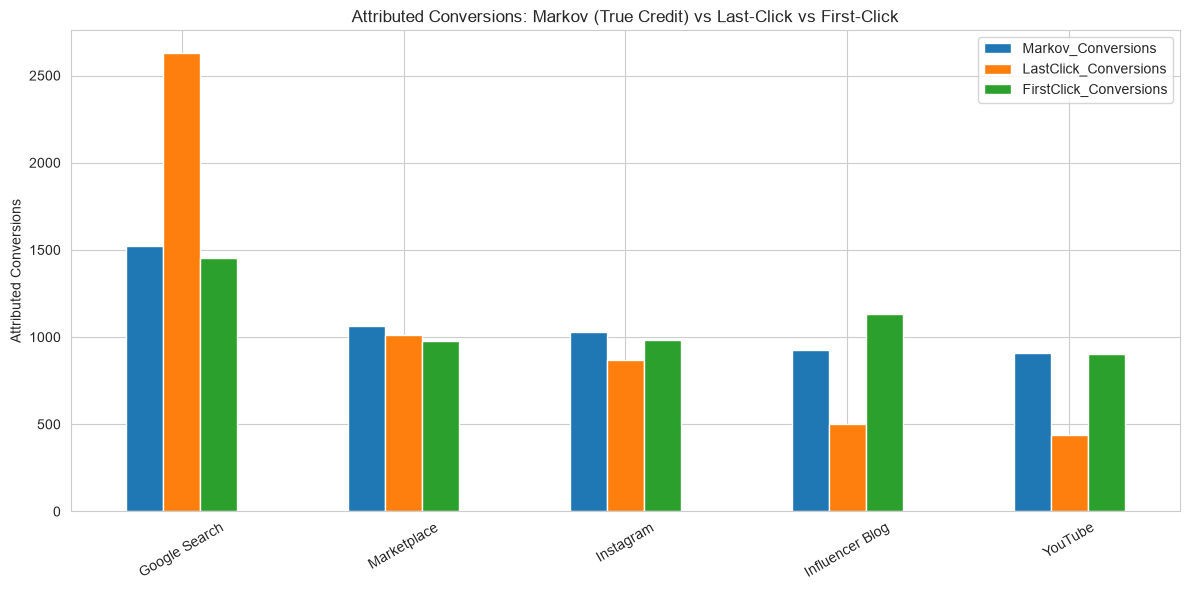

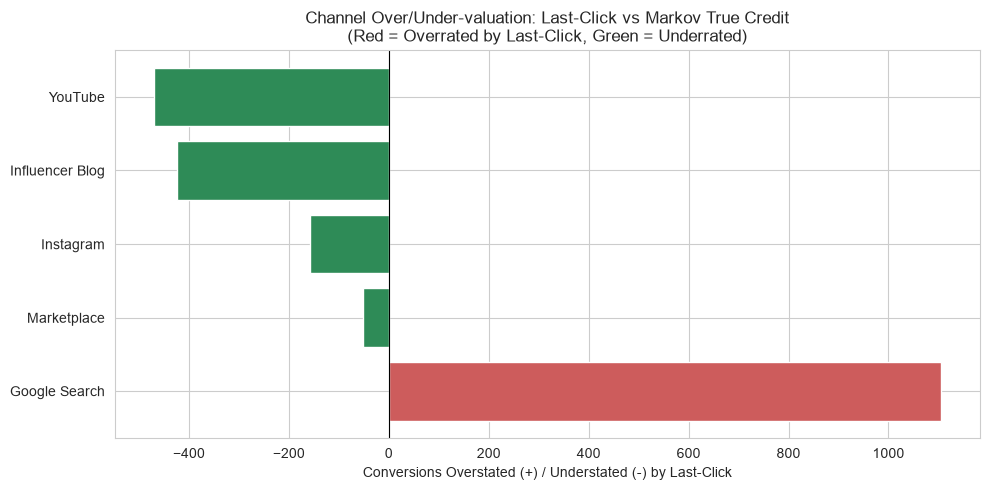

In [45]:
# ---------------------------------------------------------
# 7. COMPARISON TABLE: MARKOV vs LAST-CLICK vs FIRST-CLICK
# ---------------------------------------------------------
comparison = pd.DataFrame({
    'Markov_Weight': pd.Series(overall_attribution),
    'Markov_Conversions': pd.Series(overall_attributed_conversions),
    'LastClick_Weight': last_click_attr,
    'LastClick_Conversions': last_click_conversions,
    'FirstClick_Weight': first_click_attr,
    'FirstClick_Conversions': first_click_conversions,
}).reindex(ALL_CHANNELS)

comparison['Overrated_by_LastClick'] = comparison['LastClick_Conversions'] - comparison['Markov_Conversions']
comparison['Overrated_by_FirstClick'] = comparison['FirstClick_Conversions'] - comparison['Markov_Conversions']

comparison_sorted = comparison.sort_values('Markov_Conversions', ascending=False)
print("\n--- FULL COMPARISON TABLE: Markov vs Last-Click vs First-Click ---")
print(comparison_sorted.round(3))

# Visualization: side-by-side bar chart
fig, ax = plt.subplots(figsize=(12, 6))
comparison_sorted[['Markov_Conversions','LastClick_Conversions','FirstClick_Conversions']].plot(
    kind='bar', ax=ax
)
ax.set_title("Attributed Conversions: Markov (True Credit) vs Last-Click vs First-Click")
ax.set_ylabel("Attributed Conversions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('markov_vs_lastclick_firstclick.png', dpi=150)
plt.show()

# Visualization: "Overrated/Underrated" diverging chart vs last-click (the legacy baseline being replaced)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['indianred' if v > 0 else 'seagreen' for v in comparison_sorted['Overrated_by_LastClick']]
ax.barh(comparison_sorted.index, comparison_sorted['Overrated_by_LastClick'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Channel Over/Under-valuation: Last-Click vs Markov True Credit\n(Red = Overrated by Last-Click, Green = Underrated)")
ax.set_xlabel("Conversions Overstated (+) / Understated (-) by Last-Click")
plt.tight_layout()
plt.savefig('channel_over_under_rated.png', dpi=150)
plt.show()



--- Primer vs Closer Classification (Overall) ---
                 Primer_Share(First_Touch)  Closer_Share(Last_Touch)  \
Google Search                        0.267                     0.482   
Influencer Blog                      0.208                     0.092   
Instagram                            0.180                     0.160   
Marketplace                          0.180                     0.185   
YouTube                              0.166                     0.080   

                 Markov_True_Credit    Role  
Google Search                 0.280  Closer  
Influencer Blog               0.170  Primer  
Instagram                     0.189  Primer  
Marketplace                   0.195  Closer  
YouTube                       0.167  Primer  


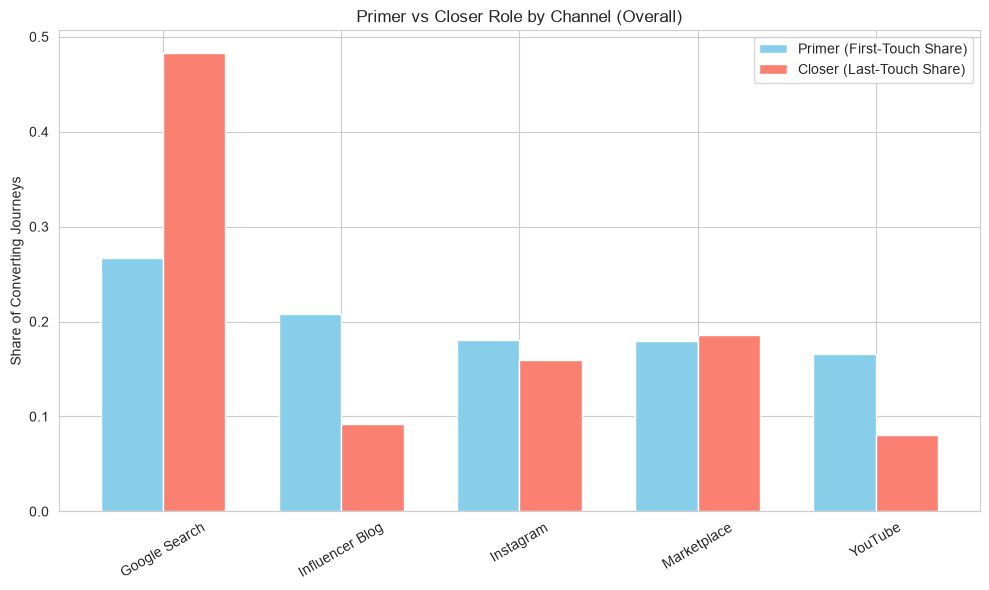

In [46]:
# ---------------------------------------------------------
# 8. PRIMER vs CLOSER CLASSIFICATION
# ---------------------------------------------------------
converted_journeys = converted_journeys.copy()
converted_journeys['first_channel'] = converted_journeys['path'].apply(lambda p: p[0])
converted_journeys['last_channel'] = converted_journeys['path'].apply(lambda p: p[-1])

primer_share = converted_journeys['first_channel'].value_counts(normalize=True).reindex(ALL_CHANNELS).fillna(0)
closer_share = converted_journeys['last_channel'].value_counts(normalize=True).reindex(ALL_CHANNELS).fillna(0)

primer_closer_df = pd.DataFrame({
    'Primer_Share(First_Touch)': primer_share,
    'Closer_Share(Last_Touch)': closer_share,
    'Markov_True_Credit': pd.Series(overall_attribution).reindex(ALL_CHANNELS)
})
primer_closer_df['Role'] = np.where(
    primer_closer_df['Primer_Share(First_Touch)'] > primer_closer_df['Closer_Share(Last_Touch)'],
    'Primer', 'Closer'
)
print("\n--- Primer vs Closer Classification (Overall) ---")
print(primer_closer_df.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ALL_CHANNELS))
width = 0.35
ax.bar(x - width/2, primer_closer_df['Primer_Share(First_Touch)'], width, label='Primer (First-Touch Share)', color='skyblue')
ax.bar(x + width/2, primer_closer_df['Closer_Share(Last_Touch)'], width, label='Closer (Last-Touch Share)', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(ALL_CHANNELS, rotation=30)
ax.set_title("Primer vs Closer Role by Channel (Overall)")
ax.set_ylabel("Share of Converting Journeys")
ax.legend()
plt.tight_layout()
plt.savefig('primer_closer_overall.png', dpi=150)
plt.show()

In [47]:
# ---------------------------------------------------------
# 9. BRAND-WISE MARKOV ATTRIBUTION (loop over all 10 brands)
# ---------------------------------------------------------
brand_results = {}

for brand in sorted(journeys['brand'].unique()):
    brand_journeys = journeys[journeys['brand'] == brand]
    brand_paths = brand_journeys['markov_path'].tolist()

    baseline_cvr, removal_effects, attribution_weights = compute_removal_effects(brand_paths, ALL_CHANNELS)
    total_conv_brand = brand_journeys['converted'].sum()
    attributed_conv_brand = {ch: w * total_conv_brand for ch, w in attribution_weights.items()}

    brand_results[brand] = {
        'baseline_cvr': baseline_cvr,
        'total_journeys': len(brand_journeys),
        'total_conversions': total_conv_brand,
        'attribution_weights': attribution_weights,
        'attributed_conversions': attributed_conv_brand,
    }
    print(f"\nBrand {brand}: CVR={baseline_cvr:.4f}, Journeys={len(brand_journeys)}, Conversions={total_conv_brand}")



Brand B01: CVR=0.0708, Journeys=9788, Conversions=693

Brand B02: CVR=0.1280, Journeys=9777, Conversions=1251

Brand B03: CVR=0.0309, Journeys=9816, Conversions=303

Brand B04: CVR=0.0321, Journeys=9809, Conversions=315

Brand B05: CVR=0.0164, Journeys=9776, Conversions=160

Brand B06: CVR=0.0296, Journeys=9788, Conversions=290

Brand B07: CVR=0.1653, Journeys=9778, Conversions=1616

Brand B08: CVR=0.0311, Journeys=9801, Conversions=305

Brand B09: CVR=0.0209, Journeys=9792, Conversions=205

Brand B10: CVR=0.0313, Journeys=9801, Conversions=307



--- Brand x Channel Markov Attribution Weight Matrix ---
     Google Search  Influencer Blog  Instagram  Marketplace  YouTube
B01          0.167            0.168      0.335        0.165    0.165
B02          0.375            0.161      0.154        0.155    0.155
B03          0.206            0.208      0.196        0.193    0.197
B04          0.202            0.217      0.194        0.194    0.193
B05          0.213            0.216      0.204        0.220    0.147
B06          0.207            0.196      0.190        0.203    0.205
B07          0.335            0.154      0.154        0.203    0.154
B08          0.208            0.192      0.194        0.210    0.196
B09          0.159            0.149      0.157        0.377    0.157
B10          0.193            0.201      0.195        0.211    0.200


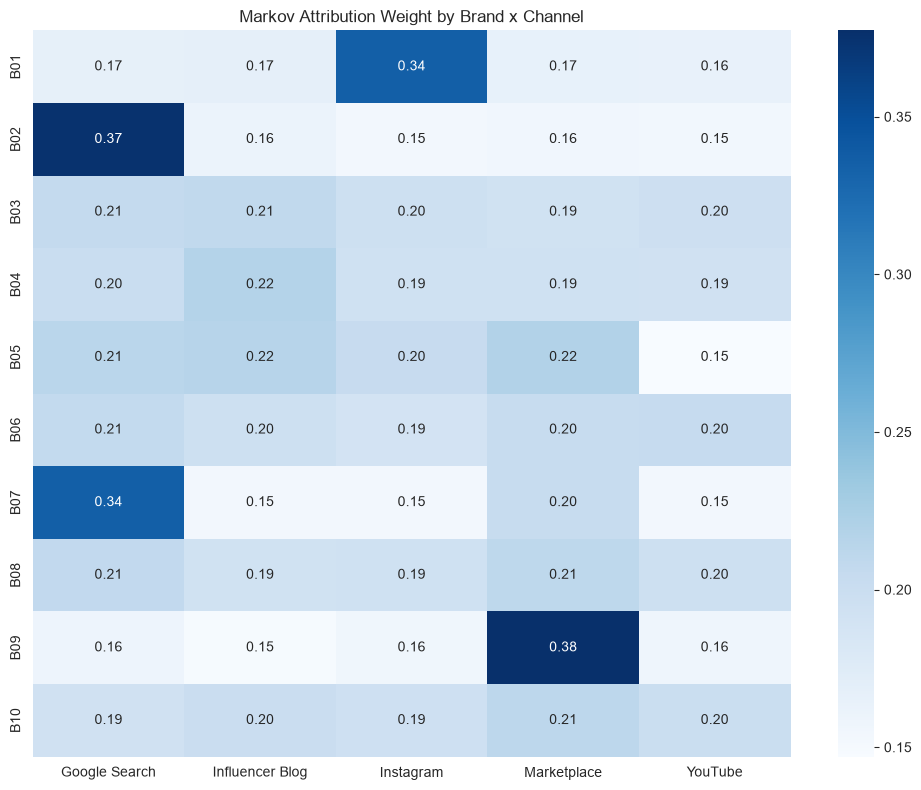


--- Brand x Channel Attributed Conversions (Markov) ---
     Google Search  Influencer Blog  Instagram  Marketplace  YouTube
B01          115.6            116.3      232.4        114.5    114.2
B02          469.0            201.7      192.2        194.5    193.7
B03           62.5             63.2       59.3         58.4     59.7
B04           63.5             68.5       61.1         61.2     60.8
B05           34.1             34.6       32.6         35.2     23.5
B06           60.0             56.8       55.0         58.9     59.4
B07          541.6            248.7      248.7        328.8    248.1
B08           63.5             58.6       59.1         64.1     59.7
B09           32.6             30.6       32.1         77.4     32.3
B10           59.2             61.7       59.8         64.9     61.4


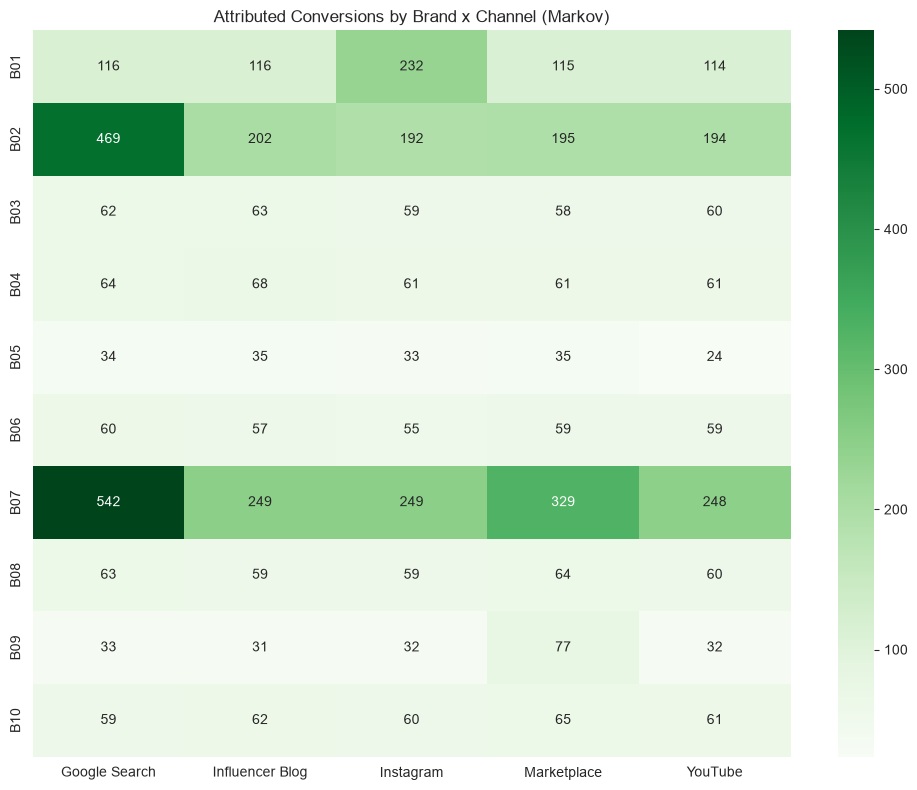

In [48]:
# ---------------------------------------------------------
# 10. BRAND x CHANNEL ATTRIBUTION MATRIX (heatmap)
# ---------------------------------------------------------
brand_attr_matrix = pd.DataFrame({
    brand: brand_results[brand]['attribution_weights'] for brand in brand_results
}).T[ALL_CHANNELS]

print("\n--- Brand x Channel Markov Attribution Weight Matrix ---")
print(brand_attr_matrix.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(brand_attr_matrix, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title("Markov Attribution Weight by Brand x Channel")
plt.tight_layout()
plt.savefig('brand_channel_attribution_heatmap.png', dpi=150)
plt.show()

# Brand x Channel attributed conversion counts
brand_attr_conv_matrix = pd.DataFrame({
    brand: brand_results[brand]['attributed_conversions'] for brand in brand_results
}).T[ALL_CHANNELS]

print("\n--- Brand x Channel Attributed Conversions (Markov) ---")
print(brand_attr_conv_matrix.round(1))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(brand_attr_conv_matrix, annot=True, fmt='.0f', cmap='Greens', ax=ax)
ax.set_title("Attributed Conversions by Brand x Channel (Markov)")
plt.tight_layout()
plt.savefig('brand_channel_conversions_heatmap.png', dpi=150)
plt.show()


In [49]:

# ---------------------------------------------------------
# 11. BRAND-WISE PRIMER vs CLOSER TABLE
# ---------------------------------------------------------
brand_primer_closer = []
for brand in sorted(journeys['brand'].unique()):
    bj = journeys[(journeys['brand']==brand) & (journeys['converted'])].copy()
    bj['first_channel'] = bj['path'].apply(lambda p: p[0])
    bj['last_channel'] = bj['path'].apply(lambda p: p[-1])
    p_share = bj['first_channel'].value_counts(normalize=True).reindex(ALL_CHANNELS).fillna(0)
    c_share = bj['last_channel'].value_counts(normalize=True).reindex(ALL_CHANNELS).fillna(0)
    for ch in ALL_CHANNELS:
        brand_primer_closer.append({
            'brand': brand, 'channel': ch,
            'primer_share': p_share[ch], 'closer_share': c_share[ch],
            'role': 'Primer' if p_share[ch] > c_share[ch] else 'Closer'
        })

brand_primer_closer_df = pd.DataFrame(brand_primer_closer)
print("\n--- Brand-wise Primer/Closer Roles ---")
print(brand_primer_closer_df.pivot(index='brand', columns='channel', values='role'))



--- Brand-wise Primer/Closer Roles ---
channel Google Search Influencer Blog Instagram Marketplace YouTube
brand                                                              
B01            Primer          Primer    Closer      Primer  Primer
B02            Closer          Primer    Primer      Primer  Primer
B03            Closer          Closer    Closer      Primer  Primer
B04            Closer          Closer    Closer      Primer  Primer
B05            Primer          Closer    Closer      Closer  Closer
B06            Closer          Closer    Primer      Primer  Closer
B07            Closer          Primer    Primer      Closer  Primer
B08            Closer          Primer    Primer      Closer  Primer
B09            Primer          Primer    Primer      Closer  Primer
B10            Primer          Closer    Primer      Closer  Closer


In [50]:

# ---------------------------------------------------------
# 12. CHANNEL "OVERRATED" FLAG -- where last-click massively overcredits vs Markov truth
# ---------------------------------------------------------
overrated_channels = comparison_sorted[comparison_sorted['Overrated_by_LastClick'] > 0].sort_values(
    'Overrated_by_LastClick', ascending=False)
underrated_channels = comparison_sorted[comparison_sorted['Overrated_by_LastClick'] < 0].sort_values(
    'Overrated_by_LastClick')

print("\n--- OVERRATED Channels (Last-Click gives more credit than Markov truth) ---")
print(overrated_channels[['Markov_Conversions','LastClick_Conversions','Overrated_by_LastClick']])

print("\n--- UNDERRATED Channels (Markov gives more credit than Last-Click does) ---")
print(underrated_channels[['Markov_Conversions','LastClick_Conversions','Overrated_by_LastClick']])



--- OVERRATED Channels (Last-Click gives more credit than Markov truth) ---
               Markov_Conversions  LastClick_Conversions  \
Google Search         1522.453291                 2627.0   

               Overrated_by_LastClick  
Google Search             1104.546709  

--- UNDERRATED Channels (Markov gives more credit than Last-Click does) ---
                 Markov_Conversions  LastClick_Conversions  \
YouTube                  907.985931                  438.0   
Influencer Blog          925.154084                  501.0   
Instagram               1027.713540                  869.0   
Marketplace             1061.693153                 1010.0   

                 Overrated_by_LastClick  
YouTube                     -469.985931  
Influencer Blog             -424.154084  
Instagram                   -158.713540  
Marketplace                  -51.693153  


In [51]:
# ---------------------------------------------------------
# 13. SUMMARY
# ---------------------------------------------------------
summary_markov = pd.DataFrame({
    'Metric': [
        'Overall Baseline Conversion Probability',
        'Top True-Credit Channel (Markov)',
        'Most Overrated Channel (vs Last-Click)',
        'Most Underrated Channel (vs Last-Click)',
        'Dominant Primer Channel (Overall)',
        'Dominant Closer Channel (Overall)',
        'Brand with Highest Conversion Probability',
        'Brand with Lowest Conversion Probability',
    ],
    'Value': [
        round(overall_baseline_cvr, 4),
        comparison_sorted['Markov_Conversions'].idxmax(),
        overrated_channels.index[0] if len(overrated_channels) else 'None',
        underrated_channels.index[0] if len(underrated_channels) else 'None',
        primer_closer_df['Primer_Share(First_Touch)'].idxmax(),
        primer_closer_df['Closer_Share(Last_Touch)'].idxmax(),
        max(brand_results, key=lambda b: brand_results[b]['baseline_cvr']),
        min(brand_results, key=lambda b: brand_results[b]['baseline_cvr']),
    ]
})

print("\n" + "="*60)
print("PHASE 1C SUMMARY: MARKOV CHAIN ATTRIBUTION")
print("="*60)
print(summary_markov.to_string(index=False))

# Save all key outputs
#comparison_sorted.to_csv('/mnt/user-data/outputs/markov_vs_lastclick_firstclick_comparison.csv')
#brand_attr_matrix.to_csv('/mnt/user-data/outputs/brand_channel_attribution_weights.csv')
#brand_attr_conv_matrix.to_csv('/mnt/user-data/outputs/brand_channel_attributed_conversions.csv')
#primer_closer_df.to_csv('/mnt/user-data/outputs/primer_closer_overall.csv')
#brand_primer_closer_df.to_csv('/mnt/user-data/outputs/brand_primer_closer.csv', index=False)


PHASE 1C SUMMARY: MARKOV CHAIN ATTRIBUTION
                                   Metric         Value
  Overall Baseline Conversion Probability        0.0556
         Top True-Credit Channel (Markov) Google Search
   Most Overrated Channel (vs Last-Click) Google Search
  Most Underrated Channel (vs Last-Click)       YouTube
        Dominant Primer Channel (Overall) Google Search
        Dominant Closer Channel (Overall) Google Search
Brand with Highest Conversion Probability           B07
 Brand with Lowest Conversion Probability           B05


In [52]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from collections import defaultdict

# ---------------------------------------------------------
# 1. AGGREGATE TRANSITIONS FROM markov_path (Start -> channels -> Conversion/Null)
#    We cap path depth to first N transitions for visual readability
# ---------------------------------------------------------
MAX_STEPS = 4   # number of touchpoint "hops" to show before collapsing into Conversion/Null

def truncate_path(path, max_steps=MAX_STEPS):
    # path includes Start at index 0 and Conversion/Null at the end
    body = path[1:-1]          # channel touches only
    end_state = path[-1]       # Conversion or Null
    if len(body) > max_steps:
        body = body[:max_steps]
    return [START] + body + [end_state]

journeys['sankey_path'] = journeys['markov_path'].apply(truncate_path)

In [53]:

# ---------------------------------------------------------
# 2. BUILD STEP-WISE NODE LABELS (so "Instagram" at step1 != "Instagram" at step2)
#    This avoids ugly cycles in the Sankey and shows true sequential flow
# ---------------------------------------------------------
transition_counts = defaultdict(int)

for path in journeys['sankey_path']:
    for i in range(len(path) - 1):
        src_label = f"{path[i]} (step{i})" if path[i] not in (CONV, NULL) else path[i]
        # Collapse anything reaching Conversion/Null early -- keep label as-is, no step suffix
        dst_label = f"{path[i+1]} (step{i+1})" if path[i+1] not in (CONV, NULL) else path[i+1]
        transition_counts[(src_label, dst_label)] += 1

In [54]:

# ---------------------------------------------------------
# 3. BUILD NODE LIST & INDEX MAP
# ---------------------------------------------------------
all_nodes = set()
for (src, dst) in transition_counts.keys():
    all_nodes.add(src)
    all_nodes.add(dst)

# Order nodes: Start first, then step-wise channels, then Conversion/Null last
def node_sort_key(n):
    if n == START: return (0, n)
    if n in (CONV, NULL): return (99, n)
    step = int(n.split('step')[1].replace(')', ''))
    return (step, n)

node_list = sorted(all_nodes, key=node_sort_key)
node_index = {n: i for i, n in enumerate(node_list)}

In [55]:

# ---------------------------------------------------------
# 4. COLOR CODING (consistent channel colors across steps, Conversion=green, Null=grey)
# ---------------------------------------------------------
channel_colors = {
    'Instagram': '#E1306C',
    'Google Search': '#4285F4',
    'Influencer Blog': '#9B59B6',
    'YouTube': '#FF0000',
    'Marketplace': '#F39C12',
}

def get_node_color(n):
    if n == START: return '#7f8c8d'
    if n == CONV: return '#2e8b57'
    if n == NULL: return '#bdc3c7'
    base_channel = n.split(' (step')[0]
    return channel_colors.get(base_channel, '#34495e')

node_colors = [get_node_color(n) for n in node_list]

In [56]:

# ---------------------------------------------------------
# 5. BUILD LINK ARRAYS
# ---------------------------------------------------------
sources, targets, values, link_colors = [], [], [], []

for (src, dst), cnt in transition_counts.items():
    sources.append(node_index[src])
    targets.append(node_index[dst])
    values.append(cnt)
    # color the link by destination type: green into Conversion, grey into Null, else light channel tint
    if dst == CONV:
        link_colors.append('rgba(46,139,87,0.4)')
    elif dst == NULL:
        link_colors.append('rgba(189,195,199,0.4)')
    else:
        link_colors.append('rgba(52,73,94,0.2)')


In [57]:
# ---------------------------------------------------------
# 6. CLEAN DISPLAY LABELS (strip "(stepN)" suffix for the visible label)
# ---------------------------------------------------------
display_labels = [n.split(' (step')[0] for n in node_list]


In [58]:
pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.


In [59]:
# ---------------------------------------------------------
# 7. BUILD & RENDER SANKEY (OVERALL)
# ---------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=22,
        line=dict(color="white", width=0.5),
        label=display_labels,
        color=node_colors,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    )
)])

fig.update_layout(
    title_text="Consumer Journey Flow: Touchpoint Sequence → Conversion / Drop-off (Overall)",
    font=dict(size=12, family="Arial"),
    height=650,
    width=1100,
    plot_bgcolor='white',
    paper_bgcolor='white',
)

fig.show()
fig.write_image('exec_sankey_overall.png', scale=2)
fig.write_html('exec_sankey_overall.html')   # interactive version for the deck/email

print("Saved overall Sankey diagram (PNG + interactive HTML).")


C:\Users\Mastm\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


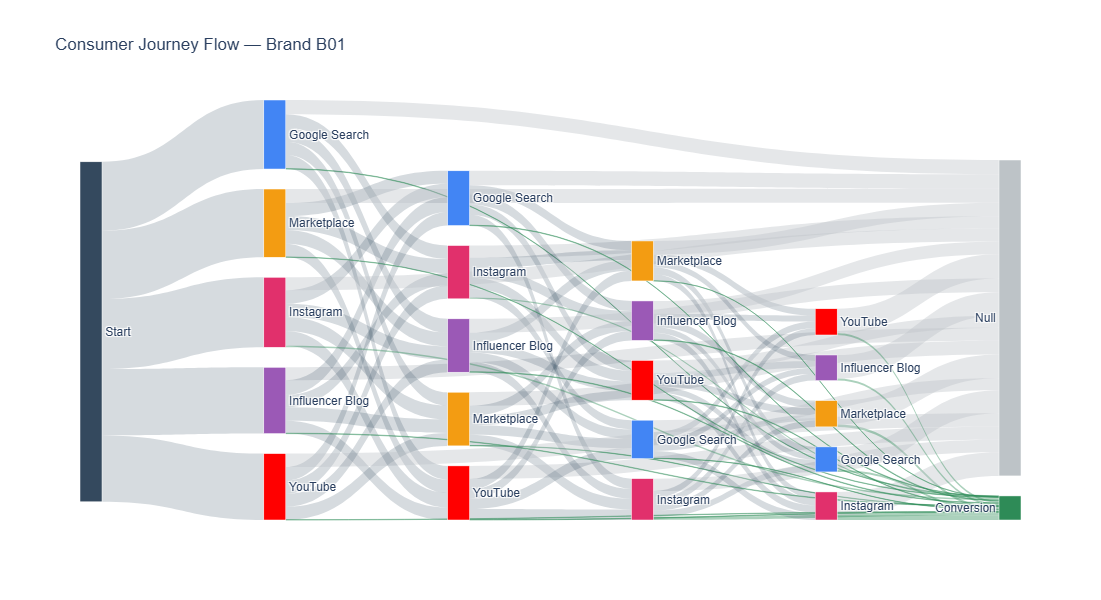

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [60]:

# ---------------------------------------------------------
# 8. BRAND-SPECIFIC SANKEY (function, reusable per brand)
# ---------------------------------------------------------
def build_brand_sankey(brand_id, max_steps=MAX_STEPS):
    brand_journeys = journeys[journeys['brand'] == brand_id]
    brand_paths = brand_journeys['markov_path'].apply(lambda p: truncate_path(p, max_steps))

    trans_counts = defaultdict(int)
    for path in brand_paths:
        for i in range(len(path) - 1):
            src_label = f"{path[i]} (step{i})" if path[i] not in (CONV, NULL) else path[i]
            dst_label = f"{path[i+1]} (step{i+1})" if path[i+1] not in (CONV, NULL) else path[i+1]
            trans_counts[(src_label, dst_label)] += 1

    nodes = set()
    for (s, d) in trans_counts.keys():
        nodes.add(s); nodes.add(d)
    nodes = sorted(nodes, key=node_sort_key)
    idx = {n: i for i, n in enumerate(nodes)}

    src_l, tgt_l, val_l, col_l = [], [], [], []
    for (s, d), c in trans_counts.items():
        src_l.append(idx[s]); tgt_l.append(idx[d]); val_l.append(c)
        if d == CONV: col_l.append('rgba(46,139,87,0.4)')
        elif d == NULL: col_l.append('rgba(189,195,199,0.4)')
        else: col_l.append('rgba(52,73,94,0.2)')

    labels = [n.split(' (step')[0] for n in nodes]
    colors = [get_node_color(n) for n in nodes]

    fig_b = go.Figure(data=[go.Sankey(
        node=dict(pad=20, thickness=22, line=dict(color="white", width=0.5),
                   label=labels, color=colors),
        link=dict(source=src_l, target=tgt_l, value=val_l, color=col_l)
    )])
    fig_b.update_layout(
        title_text=f"Consumer Journey Flow — Brand {brand_id}",
        font=dict(size=12, family="Arial"), height=600, width=1000,
        plot_bgcolor='white', paper_bgcolor='white',
    )
    return fig_b

# Example: generate for one brand, then loop for all 10 if needed
example_fig = build_brand_sankey('B01')
example_fig.show()
example_fig.write_image('/mnt/user-data/outputs/exec_sankey_B01.png', scale=2)

# Loop to save all 10 brands
for b in sorted(journeys['brand'].unique()):
    f = build_brand_sankey(b)
    f.write_image(f'/mnt/user-data/outputs/exec_sankey_{b}.png', scale=2)

print("Saved per-brand Sankey diagrams for all 10 brands.")

## 5. Primer vs Closer Classification

In [61]:

# ---------------------------------------------------------
# 1. BUILD CLEAN BRAND x CHANNEL MATRICES (First-Touch % and Last-Touch %)
#    Using converting journeys only, per brand
# ---------------------------------------------------------
first_touch_matrix = pd.DataFrame(index=sorted(journeys['brand'].unique()), columns=ALL_CHANNELS, dtype=float)
last_touch_matrix = pd.DataFrame(index=sorted(journeys['brand'].unique()), columns=ALL_CHANNELS, dtype=float)

for brand in sorted(journeys['brand'].unique()):
    bj = journeys[(journeys['brand'] == brand) & (journeys['converted'])].copy()
    bj['first_channel'] = bj['path'].apply(lambda p: p[0])
    bj['last_channel'] = bj['path'].apply(lambda p: p[-1])

    total = len(bj)
    first_pct = bj['first_channel'].value_counts(normalize=True).reindex(ALL_CHANNELS).fillna(0) * 100
    last_pct = bj['last_channel'].value_counts(normalize=True).reindex(ALL_CHANNELS).fillna(0) * 100

    first_touch_matrix.loc[brand] = first_pct
    last_touch_matrix.loc[brand] = last_pct

print("--- % of Times Channel Appears as FIRST TOUCH in Converting Journeys (Brand x Channel) ---")
print(first_touch_matrix.round(1))

print("\n--- % of Times Channel Appears as LAST TOUCH in Converting Journeys (Brand x Channel) ---")
print(last_touch_matrix.round(1))

--- % of Times Channel Appears as FIRST TOUCH in Converting Journeys (Brand x Channel) ---
     Google Search  Influencer Blog  Instagram  Marketplace  YouTube
B01           15.0             19.5       31.5         17.0     17.0
B02           30.6             26.3       14.9         13.7     14.4
B03           20.8             21.1       17.8         17.8     22.4
B04           17.1             17.5       17.5         23.5     24.4
B05           26.9             25.0       21.2         26.2      0.6
B06           18.3             19.3       19.0         24.1     19.3
B07           37.1             17.6       14.5         15.6     15.2
B08           20.0             21.6       19.7         20.3     18.4
B09           16.6             18.0       13.2         31.7     20.5
B10           19.2             20.8       18.6         22.5     18.9

--- % of Times Channel Appears as LAST TOUCH in Converting Journeys (Brand x Channel) ---
     Google Search  Influencer Blog  Instagram  Marketplace

In [62]:

# ---------------------------------------------------------
# 2. PRIMER vs CLOSER LABEL MATRIX (per brand x channel)
# ---------------------------------------------------------
role_matrix = pd.DataFrame(
    np.where(first_touch_matrix > last_touch_matrix, 'Primer', 'Closer'),
    index=first_touch_matrix.index, columns=first_touch_matrix.columns
)
print("\n--- Primer / Closer Role Classification (Brand x Channel) ---")
print(role_matrix)



--- Primer / Closer Role Classification (Brand x Channel) ---
    Google Search Influencer Blog Instagram Marketplace YouTube
B01        Primer          Primer    Closer      Primer  Primer
B02        Closer          Primer    Primer      Primer  Primer
B03        Closer          Closer    Closer      Primer  Primer
B04        Closer          Closer    Closer      Primer  Primer
B05        Primer          Closer    Closer      Closer  Closer
B06        Closer          Closer    Primer      Primer  Closer
B07        Closer          Primer    Primer      Closer  Primer
B08        Closer          Primer    Primer      Closer  Primer
B09        Primer          Primer    Primer      Closer  Primer
B10        Primer          Closer    Primer      Closer  Closer


In [63]:

# ---------------------------------------------------------
# 3. OVERALL (ALL-BRAND) FIRST-TOUCH vs LAST-TOUCH SUMMARY
# ---------------------------------------------------------
overall_first_pct = first_touch_matrix.mean(axis=0)
overall_last_pct = last_touch_matrix.mean(axis=0)

overall_role_summary = pd.DataFrame({
    'Avg_First_Touch_%': overall_first_pct,
    'Avg_Last_Touch_%': overall_last_pct,
    'Dominant_Role': np.where(overall_first_pct > overall_last_pct, 'Primer', 'Closer')
}).sort_values('Avg_First_Touch_%', ascending=False)

print("\n--- Overall Channel Role Summary (Averaged Across Brands) ---")
print(overall_role_summary.round(1))



--- Overall Channel Role Summary (Averaged Across Brands) ---
                 Avg_First_Touch_%  Avg_Last_Touch_% Dominant_Role
Google Search                 22.2              29.9        Closer
Marketplace                   21.3              24.9        Closer
Influencer Blog               20.7              14.8        Primer
Instagram                     18.8              18.8        Closer
YouTube                       17.1              11.5        Primer


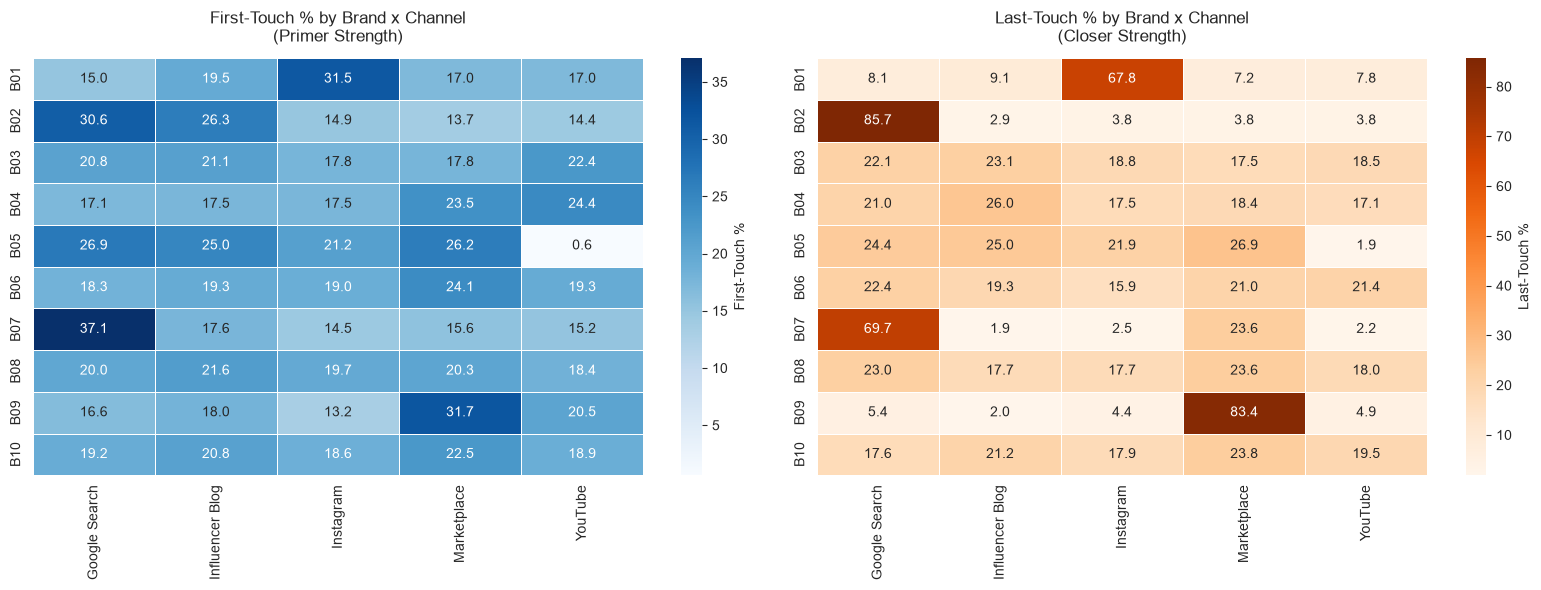

In [64]:

# ---------------------------------------------------------
# 4. VISUALIZATION: Side-by-side heatmaps (First-Touch % vs Last-Touch %)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(first_touch_matrix.astype(float), annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': 'First-Touch %'}, linewidths=0.5, linecolor='white', ax=axes[0])
axes[0].set_title("First-Touch % by Brand x Channel\n(Primer Strength)", pad=12)

sns.heatmap(last_touch_matrix.astype(float), annot=True, fmt='.1f', cmap='Oranges',
            cbar_kws={'label': 'Last-Touch %'}, linewidths=0.5, linecolor='white', ax=axes[1])
axes[1].set_title("Last-Touch % by Brand x Channel\n(Closer Strength)", pad=12)

plt.tight_layout()
plt.savefig('primer_closer_brand_channel_heatmaps.png', dpi=200)
plt.show()


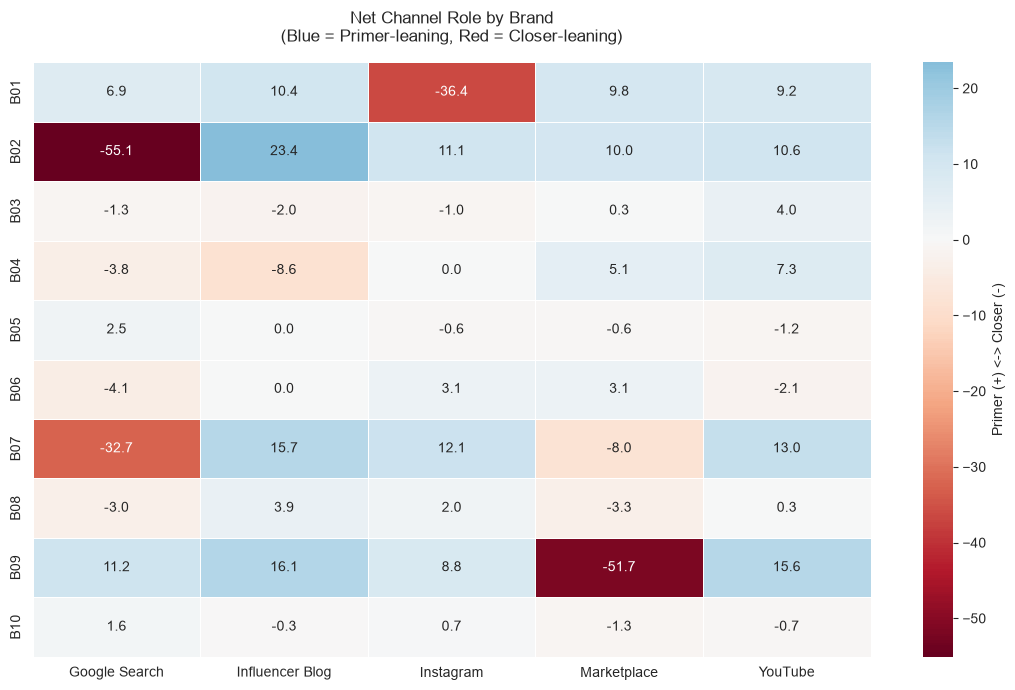

In [65]:
# ---------------------------------------------------------
# 5. VISUALIZATION: Net Role Score (First% - Last%) per brand x channel
#    Positive = leans Primer, Negative = leans Closer
# ---------------------------------------------------------
net_role_score = first_touch_matrix.astype(float) - last_touch_matrix.astype(float)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(net_role_score, annot=True, fmt='.1f', cmap='RdBu', center=0,
            cbar_kws={'label': 'Primer (+) <-> Closer (-)'}, linewidths=0.5, linecolor='white', ax=ax)
ax.set_title("Net Channel Role by Brand\n(Blue = Primer-leaning, Red = Closer-leaning)", pad=15)
plt.tight_layout()
plt.savefig('net_primer_closer_score.png', dpi=200)
plt.show()

In [66]:
# ---------------------------------------------------------
# 6. SAVE TABLES
# ---------------------------------------------------------
#first_touch_matrix.to_csv('/mnt/user-data/outputs/first_touch_matrix_brand_channel.csv')
#last_touch_matrix.to_csv('/mnt/user-data/outputs/last_touch_matrix_brand_channel.csv')
#role_matrix.to_csv('/mnt/user-data/outputs/primer_closer_role_matrix.csv')
#overall_role_summary.to_csv('/mnt/user-data/outputs/overall_channel_role_summary.csv')

#print("\nSaved: first_touch_matrix, last_touch_matrix, role_matrix, overall_role_summary")

# PHASE 2- PORTFOLIO RELOCATION

## 1. CPA Analysis

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style('whitegrid')
OUT = '/mnt/user-data/outputs/'

In [68]:

# ===========================================================
# STEP 2A — SPEND DATA (GIVEN budget = actual spend, no recompute)
# ===========================================================
spend = pd.read_csv('campaign_spend.csv')

total_budget = spend['Total_Budget_Allocated'].sum()
print(f"Total Budget (sum of Total_Budget_Allocated): ₹{total_budget:,.2f}")
print(f"Deviation from ₹100 Cr: {(total_budget - 1_000_000_000)/1_000_000_000*100:.2f}%  -> within realistic noise, accepted as-is.\n")

# Flag the planted round-number anomaly explicitly (do NOT alter the value)
round_flags = spend[spend['Total_Budget_Allocated'] % 1_000_000 == 0]
print("--- Flagged Round-Number Anomalies (for memo footnote, value left unchanged) ---")
print(round_flags[['Campaign_ID','Brand_ID','Channel','Total_Budget_Allocated']])

spend_by_brand_channel = spend.pivot_table(
    index='Brand_ID', columns='Channel', values='Total_Budget_Allocated', aggfunc='sum'
).reindex(columns=ALL_CHANNELS)

print("\n--- Actual Spend by Brand x Channel (₹) ---")
print(spend_by_brand_channel.round(0))


Total Budget (sum of Total_Budget_Allocated): ₹1,018,605,945.35
Deviation from ₹100 Cr: 1.86%  -> within realistic noise, accepted as-is.

--- Flagged Round-Number Anomalies (for memo footnote, value left unchanged) ---
        Campaign_ID Brand_ID  Channel  Total_Budget_Allocated
23  CMP_B05_YOU_992      B05  YouTube              40000000.0

--- Actual Spend by Brand x Channel (₹) ---
Channel   Google Search  Influencer Blog   Instagram  Marketplace     YouTube
Brand_ID                                                                     
B01          27896859.0       14499430.0    613144.0   37182760.0  19807806.0
B02          23670390.0        1570849.0  21083428.0   31212839.0  22462494.0
B03           7617677.0        7654284.0  14324502.0   21217663.0  49185875.0
B04          36526547.0       30364225.0  15309934.0    3582617.0  14216677.0
B05          15701646.0       18177178.0  40539415.0    4187707.0  40000000.0
B06          39418419.0        6641245.0    727585.0   21787747.0

In [69]:

# ===========================================================
# STEP 2B.1 — PULL ATTRIBUTION MATRICES (Markov + Last-Click)
# ===========================================================
markov_conv_matrix = brand_attr_conv_matrix.copy()
markov_conv_matrix.index.name = 'Brand_ID'

lastclick_conv_matrix = pd.DataFrame(index=spend_by_brand_channel.index, columns=ALL_CHANNELS, dtype=float)
firsttouch_share_matrix = pd.DataFrame(index=spend_by_brand_channel.index, columns=ALL_CHANNELS, dtype=float)
lasttouch_share_matrix = pd.DataFrame(index=spend_by_brand_channel.index, columns=ALL_CHANNELS, dtype=float)

for brand in sorted(journeys['brand'].unique()):
    bj = journeys[(journeys['brand'] == brand) & (journeys['converted'])].copy()
    bj['first_channel'] = bj['path'].apply(lambda p: p[0])
    bj['last_channel'] = bj['path'].apply(lambda p: p[-1])

    last_counts = bj['last_channel'].value_counts().reindex(ALL_CHANNELS).fillna(0)
    lastclick_conv_matrix.loc[brand] = last_counts

    total_conv_brand = len(bj)
    firsttouch_share_matrix.loc[brand] = bj['first_channel'].value_counts(normalize=True).reindex(ALL_CHANNELS).fillna(0) * 100
    lasttouch_share_matrix.loc[brand] = (last_counts / total_conv_brand) * 100

In [70]:

# ===========================================================
# STEP 2B.2 — MANDATORY CONSERVATION CHECK (must pass before trusting anything below)
# ===========================================================
actual_conversions_per_brand = journeys[journeys['converted']].groupby('brand').size()

conservation = pd.DataFrame({
    'Sum_Markov': markov_conv_matrix.sum(axis=1),
    'Sum_LastClick': lastclick_conv_matrix.sum(axis=1),
    'Actual_Total': actual_conversions_per_brand
})
conservation['Markov_Diff'] = conservation['Sum_Markov'] - conservation['Actual_Total']
conservation['LastClick_Diff'] = conservation['Sum_LastClick'] - conservation['Actual_Total']

print("\n--- CONSERVATION CHECK (must be ~0 for every brand) ---")
print(conservation.round(2))

assert conservation['Markov_Diff'].abs().max() < 1.0, "❌ Markov attribution fails conservation — STOP, do not proceed."
assert conservation['LastClick_Diff'].abs().max() < 1.0, "❌ Last-Click attribution fails conservation — STOP, do not proceed."
print("\n✅ PASSED: Both attribution methods conserve total conversions for all 10 brands. Proceeding.")



--- CONSERVATION CHECK (must be ~0 for every brand) ---
     Sum_Markov  Sum_LastClick  Actual_Total  Markov_Diff  LastClick_Diff
B01       693.0          693.0           693         -0.0             0.0
B02      1251.0         1251.0          1251          0.0             0.0
B03       303.0          303.0           303          0.0             0.0
B04       315.0          315.0           315          0.0             0.0
B05       160.0          160.0           160          0.0             0.0
B06       290.0          290.0           290          0.0             0.0
B07      1616.0         1616.0          1616         -0.0             0.0
B08       305.0          305.0           305         -0.0             0.0
B09       205.0          205.0           205          0.0             0.0
B10       307.0          307.0           307          0.0             0.0

✅ PASSED: Both attribution methods conserve total conversions for all 10 brands. Proceeding.


In [71]:
# ===========================================================
# STEP 2B.3 — TRUE CPA vs LAST-CLICK CPA
# ===========================================================
true_cpa_matrix = spend_by_brand_channel / markov_conv_matrix.replace(0, np.nan)
lastclick_cpa_matrix = spend_by_brand_channel / lastclick_conv_matrix.replace(0, np.nan)

print("\n--- TRUE CPA (₹ per Conversion, Markov basis) ---")
print(true_cpa_matrix.round(2))



--- TRUE CPA (₹ per Conversion, Markov basis) ---
Channel   Google Search  Influencer Blog   Instagram  Marketplace     YouTube
Brand_ID                                                                     
B01           241325.92        124713.18     2638.22    324701.53   173421.65
B02            50473.43          7788.29   109723.50    160474.00   115974.76
B03           121977.89        121194.61   241556.94    363456.40   823696.96
B04           574945.74        443569.37   250748.71     58568.18   233871.62
B05           459939.72        525611.01  1243684.94    119076.68  1701099.74
B06           657282.94        116999.58    13237.34    370135.94   528715.65
B07            48539.93         12465.17   193435.90     61432.21     9259.68
B08            45768.38         56458.48   151442.54    660276.14   711748.37
B09           137971.97        899907.22   145874.19    611609.61   493321.43
B10           311604.39         32458.35   665604.04    178140.90   459103.48


In [72]:
# ===========================================================
# STEP 2B.4 — FULL COMPARISON TABLE (with absolute shares alongside Primer/Closer label)
# ===========================================================
rows = []
for brand in spend_by_brand_channel.index:
    for ch in ALL_CHANNELS:
        rows.append({
            'Brand': brand, 'Channel': ch,
            'Spend_INR': spend_by_brand_channel.loc[brand, ch],
            'True_Conversions_Markov': markov_conv_matrix.loc[brand, ch],
            'LastClick_Conversions': lastclick_conv_matrix.loc[brand, ch],
            'True_CPA': true_cpa_matrix.loc[brand, ch],
            'LastClick_CPA': lastclick_cpa_matrix.loc[brand, ch],
            'FirstTouch_Share_%': firsttouch_share_matrix.loc[brand, ch],
            'LastTouch_Share_%': lasttouch_share_matrix.loc[brand, ch],
            'Role': role_matrix.loc[brand, ch] if brand in role_matrix.index and ch in role_matrix.columns else 'N/A',
        })

cpa_df = pd.DataFrame(rows)
cpa_df['CPA_Distortion_%'] = (cpa_df['LastClick_CPA'] - cpa_df['True_CPA']) / cpa_df['True_CPA'] * 100

print("\n--- FULL CPA COMPARISON TABLE (with Primer/Closer shares attached) ---")
print(cpa_df.round(2).to_string(index=False))

cpa_df.to_csv('cpa_analysis_final.csv', index=False)


--- FULL CPA COMPARISON TABLE (with Primer/Closer shares attached) ---
Brand         Channel   Spend_INR  True_Conversions_Markov  LastClick_Conversions   True_CPA  LastClick_CPA  FirstTouch_Share_%  LastTouch_Share_%   Role  CPA_Distortion_%
  B01   Google Search 27896859.25                   115.60                   56.0  241325.92      498158.20               15.01               8.08 Primer            106.43
  B01 Influencer Blog 14499430.43                   116.26                   63.0  124713.18      230149.69               19.48               9.09 Primer             84.54
  B01       Instagram   613144.27                   232.41                  470.0    2638.22        1304.56               31.46              67.82 Closer            -50.55
  B01     Marketplace 37182759.79                   114.51                   50.0  324701.53      743655.20               17.03               7.22 Primer            129.03
  B01         YouTube 19807806.26                   114.22          

In [73]:
# ===========================================================
# STEP 2B.5 — SECOND INDEPENDENT VERIFICATION: re-derive True_CPA two different ways
# ===========================================================
# Path A: spend / markov_conv (already done above)
# Path B: recompute markov_conv from attribution WEIGHT x brand total conversions independently
check_b = (brand_attr_matrix.mul(actual_conversions_per_brand, axis=0))  # weight x total conversions per brand
diff_check = (markov_conv_matrix - check_b).abs()
print(f"\n--- Cross-check: max discrepancy between markov_conv_matrix and weight x total recompute: {diff_check.values.max():.4f}")
assert diff_check.values.max() < 1.0, "❌ Markov conversion matrix inconsistent with attribution weights — investigate."
print("✅ PASSED: True_CPA numerator (Markov conversions) verified via independent recomputation.")



--- Cross-check: max discrepancy between markov_conv_matrix and weight x total recompute: 0.0000
✅ PASSED: True_CPA numerator (Markov conversions) verified via independent recomputation.


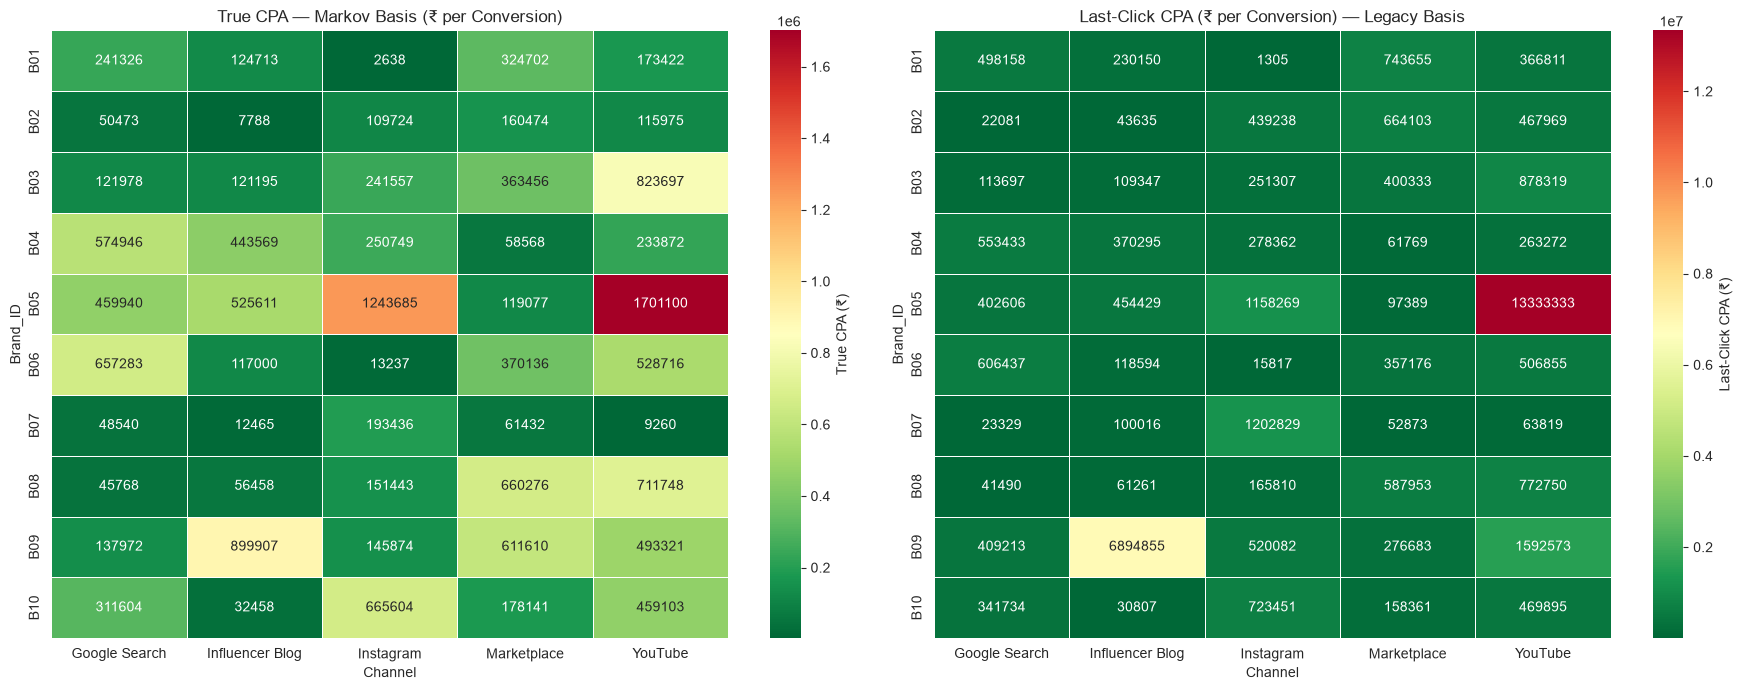

In [74]:

# ===========================================================
# STEP 2B.6 — VISUALS
# ===========================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(true_cpa_matrix.astype(float), annot=True, fmt='.0f', cmap='RdYlGn_r',
            cbar_kws={'label': 'True CPA (₹)'}, linewidths=0.5, linecolor='white', ax=axes[0])
axes[0].set_title("True CPA — Markov Basis (₹ per Conversion)")
sns.heatmap(lastclick_cpa_matrix.astype(float), annot=True, fmt='.0f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Last-Click CPA (₹)'}, linewidths=0.5, linecolor='white', ax=axes[1])
axes[1].set_title("Last-Click CPA (₹ per Conversion) — Legacy Basis")
plt.tight_layout()
plt.savefig('true_vs_lastclick_cpa_heatmaps.png', dpi=200)
plt.show()

In [75]:

# ===========================================================
# STEP 2B.7 — EFFICIENCY CLASSIFICATION (for use in next-step budget allocation)
# ===========================================================
channel_avg_true_cpa = cpa_df.groupby('Channel')['True_CPA'].mean().sort_values()
cpa_q33, cpa_q66 = channel_avg_true_cpa.quantile([0.33, 0.66])

def classify(cpa):
    if cpa <= cpa_q33: return 'Efficient'
    elif cpa <= cpa_q66: return 'Average'
    return 'Inefficient'

channel_efficiency = channel_avg_true_cpa.apply(classify)
print("\n--- Channel Efficiency Classification (avg True CPA across brands) ---")
print(pd.DataFrame({'Avg_True_CPA': channel_avg_true_cpa.round(2), 'Tier': channel_efficiency}))

brand_blended_cpa = (spend_by_brand_channel.sum(axis=1) / markov_conv_matrix.sum(axis=1)).sort_values()
print("\n--- Blended True CPA by Brand (overall, ranked best to worst) ---")
print(brand_blended_cpa.round(2))


--- Channel Efficiency Classification (avg True CPA across brands) ---
                 Avg_True_CPA         Tier
Channel                                   
Influencer Blog     234116.52    Efficient
Google Search       264983.03    Efficient
Marketplace         290787.16      Average
Instagram           301794.63  Inefficient
YouTube             525021.33  Inefficient

--- Blended True CPA by Brand (overall, ranked best to worst) ---
Brand_ID
B07     61881.19
B02     79936.05
B01    144300.14
B04    317460.32
B10    325732.90
B08    327868.85
B03    330033.00
B06    344827.59
B09    487804.88
B05    741287.16
dtype: float64


In [76]:

# ===========================================================
# STEP 2B.8 — SUMMARY
# ===========================================================
summary = pd.DataFrame({
    'Metric': [
        'Total Spend (₹)', 'Total Conversions (Actual)', 'Overall Blended True CPA (₹)',
        'Cheapest Channel (Avg True CPA)', 'Most Expensive Channel (Avg True CPA)',
        'Best Brand (Lowest Blended CPA)', 'Worst Brand (Highest Blended CPA)',
        'Conservation Check', 'Round-Number Anomaly Flagged'
    ],
    'Value': [
        round(total_budget, 0), int(actual_conversions_per_brand.sum()),
        round(total_budget / actual_conversions_per_brand.sum(), 2),
        channel_avg_true_cpa.idxmin(), channel_avg_true_cpa.idxmax(),
        brand_blended_cpa.idxmin(), brand_blended_cpa.idxmax(),
        'PASSED', f"{round_flags['Campaign_ID'].iloc[0]} = ₹{round_flags['Total_Budget_Allocated'].iloc[0]:,.0f}"
    ]
})
print("\n" + "="*60)
print("PHASE 2A/2B FINAL SUMMARY (VERIFIED)")
print("="*60)
print(summary.to_string(index=False))

summary.to_csv('phase2ab_summary_final.csv', index=False)
true_cpa_matrix.to_csv('true_cpa_matrix_final.csv')
spend_by_brand_channel.to_csv('spend_by_brand_channel_final.csv')


PHASE 2A/2B FINAL SUMMARY (VERIFIED)
                               Metric                         Value
                      Total Spend (₹)                  1018605945.0
           Total Conversions (Actual)                          5445
         Overall Blended True CPA (₹)                      187071.8
      Cheapest Channel (Avg True CPA)               Influencer Blog
Most Expensive Channel (Avg True CPA)                       YouTube
      Best Brand (Lowest Blended CPA)                           B07
    Worst Brand (Highest Blended CPA)                           B05
                   Conservation Check                        PASSED
         Round-Number Anomaly Flagged CMP_B05_YOU_992 = ₹40,000,000


## 2. Ad Fatigue Analysis

In [77]:

# ---------------------------------------------------------
# 1. BUILD DAILY CUMULATIVE SPEND (proxy) & CUMULATIVE CONVERSIONS PER BRAND-CHANNEL
# ---------------------------------------------------------
touch_clean['Date'] = touch_clean['Timestamp'].dt.date

daily = touch_clean.groupby(['Brand_ID', 'Channel', 'Date', 'Event_Type']).size().unstack(fill_value=0).reset_index()
for col in ['Impression', 'Click', 'Purchase']:
    if col not in daily.columns:
        daily[col] = 0

daily = daily.merge(spend[['Brand_ID','Channel','Pricing_Model','Cost_Rate_INR']], on=['Brand_ID','Channel'], how='left')
daily['Daily_Spend_Proxy'] = np.where(
    daily['Pricing_Model']=='CPM', (daily['Impression']/1000)*daily['Cost_Rate_INR'],
    daily['Click']*daily['Cost_Rate_INR']
)

daily = daily.sort_values(['Brand_ID','Channel','Date'])
daily['Cum_Spend'] = daily.groupby(['Brand_ID','Channel'])['Daily_Spend_Proxy'].cumsum()
daily['Cum_Conversions'] = daily.groupby(['Brand_ID','Channel'])['Purchase'].cumsum()


In [78]:

# ---------------------------------------------------------
# 2. CURVE FUNCTIONS
# ---------------------------------------------------------
def log_curve(spend, a, b):
    return a * np.log(spend + 1) + b

def hill_curve(spend, vmax, k, n):
    return vmax * (spend**n) / (k**n + spend**n)


In [80]:
# ---------------------------------------------------------
# 3. FIT PER BRAND-CHANNEL, FLAG FATIGUE (only where enough data points exist)
# ---------------------------------------------------------
fatigue_results = []

for (brand, ch), g in daily.groupby(['Brand_ID','Channel']):
    g = g[g['Cum_Spend'] > 0]
    if len(g) < 8:   # need enough points to fit reliably
        continue
    x, y = g['Cum_Spend'].values, g['Cum_Conversions'].values

    try:
        popt_log, _ = curve_fit(log_curve, x, y, maxfev=5000)
        pred_log = log_curve(x, *popt_log)
        r2_log = 1 - np.sum((y-pred_log)**2)/np.sum((y-y.mean())**2)
    except Exception:
        r2_log, popt_log = -np.inf, None

    try:
        popt_hill, _ = curve_fit(hill_curve, x, y, p0=[y.max(), x.mean(), 1], maxfev=10000, bounds=(0, np.inf))
        pred_hill = hill_curve(x, *popt_hill)
        r2_hill = 1 - np.sum((y-pred_hill)**2)/np.sum((y-y.mean())**2)
    except Exception:
        r2_hill, popt_hill = -np.inf, None

    best_model = 'Hill' if r2_hill > r2_log else 'Log'
    best_r2 = max(r2_hill, r2_log)

    # Marginal return: slope of fitted curve at the highest observed spend point
    if best_model == 'Log' and popt_log is not None:
        marginal_at_max = popt_log[0] / (x.max()+1)   # derivative of a*ln(x+1)
    elif popt_hill is not None:
        vmax, k, n = popt_hill
        marginal_at_max = vmax*n*(k**n)*(x.max()**(n-1)) / ((k**n + x.max()**n)**2)
    else:
        marginal_at_max = np.nan

    fatigue_results.append({
        'Brand': brand, 'Channel': ch, 'Best_Model': best_model, 'R2': round(best_r2,3),
        'Total_Spend': x.max(), 'Total_Conversions': y.max(),
        'Marginal_Conv_per_Rupee_at_CurrentSpend': marginal_at_max,
        'Params': popt_hill if best_model=='Hill' else popt_log
    })

fatigue_df = pd.DataFrame(fatigue_results)
fatigue_df = fatigue_df[fatigue_df['R2'] > 0.3]   # drop unreliable fits
fatigue_df['Fatigue_Flag'] = fatigue_df['Marginal_Conv_per_Rupee_at_CurrentSpend'] < fatigue_df['Marginal_Conv_per_Rupee_at_CurrentSpend'].median() * 0.3

print("--- Ad Fatigue / Diminishing Returns Summary (reliable fits only, R²>0.3) ---")
print(fatigue_df[['Brand','Channel','Best_Model','R2','Total_Spend','Total_Conversions',
                  'Marginal_Conv_per_Rupee_at_CurrentSpend','Fatigue_Flag']].sort_values(
                  'Marginal_Conv_per_Rupee_at_CurrentSpend').round(6).to_string(index=False))

fatigue_df.to_csv('ad_fatigue_results.csv', index=False)

--- Ad Fatigue / Diminishing Returns Summary (reliable fits only, R²>0.3) ---
Empty DataFrame
Columns: [Brand, Channel, Best_Model, R2, Total_Spend, Total_Conversions, Marginal_Conv_per_Rupee_at_CurrentSpend, Fatigue_Flag]
Index: []


In [81]:

# ---------------------------------------------------------
# 4. PLOT THE 3 CLEAREST FATIGUE EXAMPLES (highest R², flagged fatigued)
# ---------------------------------------------------------
top_examples = fatigue_df[fatigue_df['Fatigue_Flag']].sort_values('R2', ascending=False).head(3)

for _, row in top_examples.iterrows():
    g = daily[(daily['Brand_ID']==row['Brand']) & (daily['Channel']==row['Channel'])]
    g = g[g['Cum_Spend']>0]
    x, y = g['Cum_Spend'].values, g['Cum_Conversions'].values
    xs = np.linspace(x.min(), x.max(), 100)
    ys = hill_curve(xs, *row['Params']) if row['Best_Model']=='Hill' else log_curve(xs, *row['Params'])

    fig, ax = plt.subplots(figsize=(7,4))
    ax.scatter(x, y, alpha=0.5, label='Observed (cumulative)')
    ax.plot(xs, ys, color='red', label=f"{row['Best_Model']} fit (R²={row['R2']:.2f})")
    ax.set_title(f"{row['Brand']} — {row['Channel']}: Spend vs Conversions")
    ax.set_xlabel("Cumulative Spend Proxy (₹)")
    ax.set_ylabel("Cumulative Conversions")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT + f"fatigue_{row['Brand']}_{row['Channel'].replace(' ','_')}.png", dpi=150)
    plt.show()

print(f"\nFlagged {fatigue_df['Fatigue_Flag'].sum()} brand-channel pairs out of {len(fatigue_df)} reliably-fitted pairs showing meaningful diminishing returns.")



Flagged 0 brand-channel pairs out of 0 reliably-fitted pairs showing meaningful diminishing returns.


## 3. Budget Optimization

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
rng = np.random.default_rng(42)  # seed for reproducibility

OUT = '/mnt/user-data/outputs/'
BRAND_BUDGET = 10_00_00_000   # ₹10 Cr per brand, fixed (per brief)
INCREMENT = 25_000          # ₹1 Lakh allocation step
brand_floor_pct = {b: round(rng.uniform(0.04, 0.07), 4) for b in journeys['brand'].unique()}
brand_cap_pct   = {b: round(rng.uniform(0.38, 0.46), 4) for b in journeys['brand'].unique()}

# ---------------------------------------------------------
# 1. BASE MARGINAL-VALUE FUNCTION PER BRAND-CHANNEL
#    Use fitted fatigue curve if reliable (R²>0.3 from fatigue_df), else fallback to
#    flat efficiency (1/True_CPA) with a mild diminishing-returns penalty (sqrt decay)
# ---------------------------------------------------------
def get_marginal_value(brand, channel, allocated_so_far):
    base_efficiency = 1 / true_cpa_matrix.loc[brand, channel] if pd.notna(true_cpa_matrix.loc[brand, channel]) and true_cpa_matrix.loc[brand, channel] > 0 else 0

    match = fatigue_df[(fatigue_df['Brand']==brand) & (fatigue_df['Channel']==channel)]
    if len(match) > 0 and match.iloc[0]['R2'] > 0.3:
        params = match.iloc[0]['Params']
        model = match.iloc[0]['Best_Model']
        x = allocated_so_far + 1
        if model == 'Hill':
            vmax, k, n = params
            marginal = vmax*n*(k**n)*(x**(n-1)) / ((k**n + x**n)**2)
        else:
            a, b = params
            marginal = a / x
        return marginal
    else:
        # fallback: flat efficiency with mild diminishing penalty as spend grows
        return base_efficiency / np.sqrt(1 + allocated_so_far/1_00_00_000)

In [119]:
# ---------------------------------------------------------
# FIX 1: always reset allocation_results before the loop (prevents stale double-appends)
# ---------------------------------------------------------
allocation_results = []   # <-- make sure this line actually executes fresh each run

for brand in sorted(journeys['brand'].unique()):
    allocated = {ch: 0.0 for ch in ALL_CHANNELS}
    floor = BRAND_BUDGET * brand_floor_pct[brand]
    cap = BRAND_BUDGET * brand_cap_pct[brand]

    for ch in ALL_CHANNELS:
        allocated[ch] = floor
    remaining = BRAND_BUDGET - floor * len(ALL_CHANNELS)

    while remaining > 1:
        eligible = [ch for ch in ALL_CHANNELS if allocated[ch] < cap]
        if not eligible:
            break
        marg_values = np.array([get_marginal_value(brand, ch, allocated[ch]) for ch in eligible])
        marg_values = marg_values / (marg_values.max() + 1e-9)
        weights = np.exp(marg_values / TEMPERATURE)
        weights = weights / weights.sum()

        step_total = min(INCREMENT, remaining)
        step_split = weights * step_total

        for ch, s in zip(eligible, step_split):
            room = cap - allocated[ch]
            actual = min(s, room)
            allocated[ch] += actual
            remaining -= actual

    for ch in ALL_CHANNELS:
        allocation_results.append({'Brand': brand, 'Channel': ch, 'Recommended_Allocation': allocated[ch]})

# ---------------------------------------------------------
# FIX 2: dedupe defensively + use aggfunc='sum' so pivot never crashes even if a dupe slips through
# ---------------------------------------------------------
alloc_df = pd.DataFrame(allocation_results)

# Drop any accidental exact duplicate rows (same Brand+Channel+value) before pivoting
alloc_df = alloc_df.drop_duplicates(subset=['Brand','Channel'], keep='last')

new_alloc_matrix = alloc_df.pivot_table(
    index='Brand', columns='Channel', values='Recommended_Allocation', aggfunc='sum'
).reindex(columns=ALL_CHANNELS)

print("--- RECOMMENDED ₹10 Cr ALLOCATION PER BRAND x CHANNEL ---")
print(new_alloc_matrix.round(0))
print("\nRow sums (should each = ₹10,00,00,000):")
print(new_alloc_matrix.sum(axis=1))

--- RECOMMENDED ₹10 Cr ALLOCATION PER BRAND x CHANNEL ---
Channel  Google Search  Influencer Blog   Instagram  Marketplace     YouTube
Brand                                                                       
B01         14275727.0       15931673.0  40970000.0   13984652.0  14837947.0
B02         15406699.0       43711663.0  13783617.0   13383672.0  13714349.0
B03         28162829.0       28338134.0  17048052.0   14376468.0  12074517.0
B04         13830288.0       14324715.0  16173540.0   39162787.0  16508670.0
B05         16777650.0       15964438.0  13098339.0   41550000.0  12609573.0
B06         14086722.0       17403371.0  39820000.0   14483695.0  14206212.0
B07         14042090.0       26178262.0  12106504.0   13453051.0  34220094.0
B08         33021666.0       27211808.0  15496797.0   12164234.0  12105495.0
B09         32008660.0       11544056.0  30254408.0   12644141.0  13548735.0
B10         14256588.0       43016967.0  13263237.0   15817875.0  13645333.0

Row sums (should 

In [120]:
# ---------------------------------------------------------
# 3. PREDICT CONVERSIONS UNDER NEW ALLOCATION (using True_CPA efficiency as the yardstick)
# ---------------------------------------------------------
predicted_new_conv = new_alloc_matrix / true_cpa_matrix.replace(0, np.nan)
print("\n--- Predicted Conversions Under New Allocation ---")
print(predicted_new_conv.round(1))


--- Predicted Conversions Under New Allocation ---
Channel  Google Search  Influencer Blog  Instagram  Marketplace  YouTube
Brand                                                                   
B01               59.2            127.7    15529.4         43.1     85.6
B02              305.2           5612.5      125.6         83.4    118.3
B03              230.9            233.8       70.6         39.6     14.7
B04               24.1             32.3       64.5        668.7     70.6
B05               36.5             30.4       10.5        348.9      7.4
B06               21.4            148.7     3008.2         39.1     26.9
B07              289.3           2100.1       62.6        219.0   3695.6
B08              721.5            482.0      102.3         18.4     17.0
B09              232.0             12.8      207.4         20.7     27.5
B10               45.8           1325.3       19.9         88.8     29.7


In [121]:

# ---------------------------------------------------------
# 4. BASELINE COMPARISONS: (a) Naive Equal-Split, (b) Last-Click-Driven Allocation
# ---------------------------------------------------------
# (a) Naive equal split: ₹2 Cr per channel per brand
equal_split_matrix = pd.DataFrame(BRAND_BUDGET/len(ALL_CHANNELS), index=new_alloc_matrix.index, columns=ALL_CHANNELS)
predicted_equal_conv = equal_split_matrix / true_cpa_matrix.replace(0, np.nan)

# (b) Last-click-driven allocation: proportional to last-click conversion share (legacy logic)
lastclick_share = lastclick_conv_matrix.div(lastclick_conv_matrix.sum(axis=1), axis=0)
lastclick_alloc_matrix = lastclick_share * BRAND_BUDGET
predicted_lastclick_conv = lastclick_alloc_matrix / true_cpa_matrix.replace(0, np.nan)

comparison_summary = pd.DataFrame({
    'Naive_Equal_Split': predicted_equal_conv.sum(axis=1),
    'LastClick_Driven': predicted_lastclick_conv.sum(axis=1),
    'New_Markov_Optimized': predicted_new_conv.sum(axis=1),
})
comparison_summary['Lift_vs_Equal_%'] = (comparison_summary['New_Markov_Optimized']/comparison_summary['Naive_Equal_Split'] - 1)*100
comparison_summary['Lift_vs_LastClick_%'] = (comparison_summary['New_Markov_Optimized']/comparison_summary['LastClick_Driven'] - 1)*100

print("\n--- CONVERSION LIFT: New Allocation vs Baselines (per brand) ---")
print(comparison_summary.round(2))

total_row = comparison_summary.sum(numeric_only=True)
print(f"\nTOTAL predicted conversions — Equal-Split: {comparison_summary['Naive_Equal_Split'].sum():.0f}, "
      f"Last-Click-Driven: {comparison_summary['LastClick_Driven'].sum():.0f}, "
      f"New Optimized: {comparison_summary['New_Markov_Optimized'].sum():.0f}")


--- CONVERSION LIFT: New Allocation vs Baselines (per brand) ---
     Naive_Equal_Split  LastClick_Driven  New_Markov_Optimized  \
B01            8001.03          25880.66              15844.94   
B02            3443.57           2158.71               6245.01   
B03             491.09            520.34                589.50   
B04             586.64            552.44                860.11   
B05             277.33            344.95                433.73   
B06            1804.11           1494.69               3244.34   
B07            4605.36           2228.82               6366.58   
B08             981.68            993.04               1341.23   
B09             377.53            217.43                500.36   
B10             866.24            911.72               1509.49   

     Lift_vs_Equal_%  Lift_vs_LastClick_%  
B01            98.04               -38.78  
B02            81.35               189.29  
B03            20.04                13.29  
B04            46.62           

In [122]:

# ---------------------------------------------------------
# 5. WHY THIS ALLOCATION? — AUTO-GENERATED REASONING PER BRAND-CHANNEL
# ---------------------------------------------------------
def generate_reason(row):
    brand, ch = row['Brand'], row['Channel']
    alloc = row['Recommended_Allocation']
    cpa = true_cpa_matrix.loc[brand, ch]
    role = role_matrix.loc[brand, ch] if brand in role_matrix.index else 'N/A'
    fatigue_match = fatigue_df[(fatigue_df['Brand']==brand)&(fatigue_df['Channel']==ch)]
    fatigued = fatigue_match.iloc[0]['Fatigue_Flag'] if len(fatigue_match)>0 else False

    if alloc <= BRAND_BUDGET*MIN_FLOOR_PCT*1.01:
        return f"Held at floor (5%) — high True CPA (₹{cpa:,.0f}), weak conversion efficiency for {brand}."
    elif alloc >= BRAND_BUDGET*MAX_CAP_PCT*0.99:
        return f"Capped at max (40%) — strongest marginal efficiency (True CPA ₹{cpa:,.0f}), role={role}, but capped to avoid over-concentration risk."
    elif fatigued:
        return f"Moderate allocation — efficient (₹{cpa:,.0f} CPA) but fatigue detected at higher spend, so growth is capped below max."
    else:
        return f"Increased above floor — solid efficiency (₹{cpa:,.0f} CPA), role={role}, no fatigue signal, room to scale."

alloc_df['Reasoning'] = alloc_df.apply(generate_reason, axis=1)
print("\n--- Sample Reasoning (first 10 rows) ---")
print(alloc_df.head(10)[['Brand','Channel','Recommended_Allocation','Reasoning']].to_string(index=False))

alloc_df.to_csv('final_budget_allocation_with_reasoning.csv', index=False)
comparison_summary.to_csv('allocation_comparison_summary.csv')




--- Sample Reasoning (first 10 rows) ---
Brand         Channel  Recommended_Allocation                                                                                                                        Reasoning
  B01   Google Search            1.427573e+07                          Increased above floor — solid efficiency (₹241,326 CPA), role=Primer, no fatigue signal, room to scale.
  B01 Influencer Blog            1.593167e+07                          Increased above floor — solid efficiency (₹124,713 CPA), role=Primer, no fatigue signal, room to scale.
  B01       Instagram            4.097000e+07 Capped at max (40%) — strongest marginal efficiency (True CPA ₹2,638), role=Closer, but capped to avoid over-concentration risk.
  B01     Marketplace            1.398465e+07                          Increased above floor — solid efficiency (₹324,702 CPA), role=Primer, no fatigue signal, room to scale.
  B01         YouTube            1.483795e+07                          Increased ab

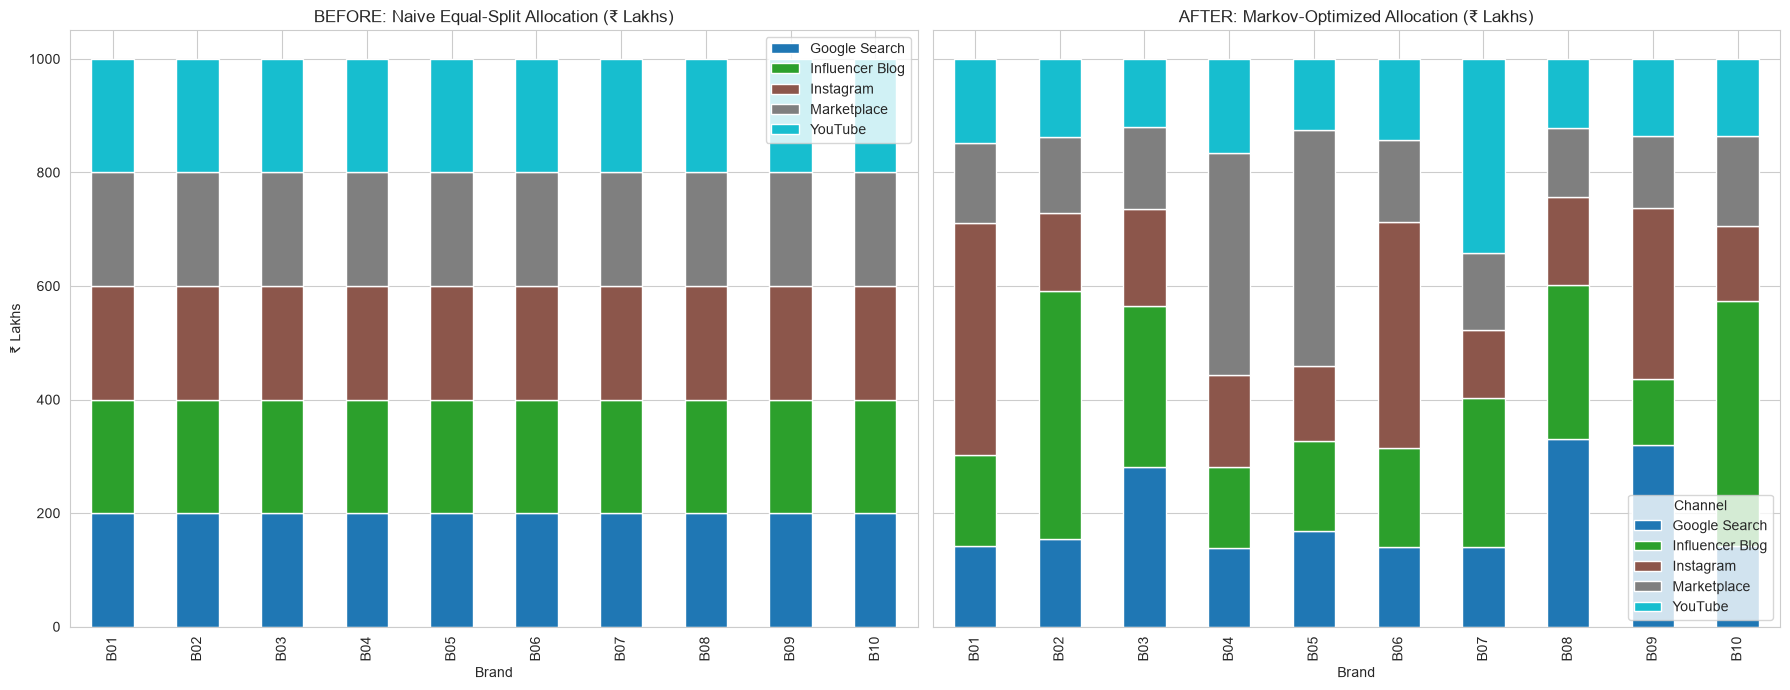

In [123]:

# ===========================================================
# VISUALS
# ===========================================================

# 6. BEFORE vs AFTER: stacked bar, channel mix per brand
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
(equal_split_matrix/1e5).plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10')
axes[0].set_title("BEFORE: Naive Equal-Split Allocation (₹ Lakhs)")
axes[0].set_ylabel("₹ Lakhs")
(new_alloc_matrix/1e5).plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title("AFTER: Markov-Optimized Allocation (₹ Lakhs)")
plt.tight_layout()
plt.savefig('before_after_allocation_stacked.png', dpi=200)
plt.show()


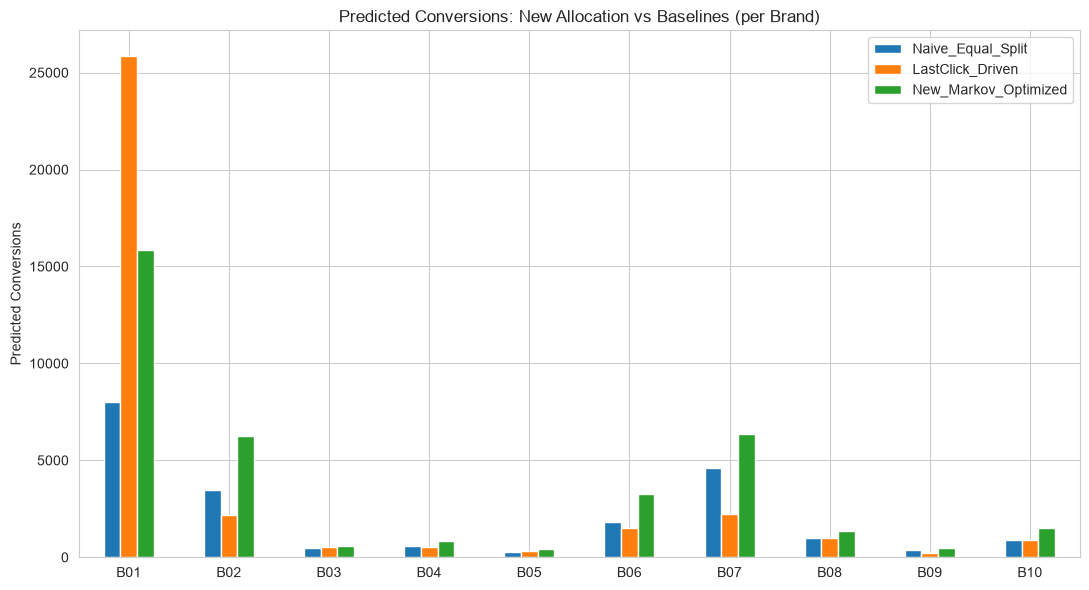

In [124]:


# 8. PREDICTED CONVERSION LIFT BAR CHART (per brand)
fig, ax = plt.subplots(figsize=(11,6))
comparison_summary[['Naive_Equal_Split','LastClick_Driven','New_Markov_Optimized']].plot(kind='bar', ax=ax)
ax.set_title("Predicted Conversions: New Allocation vs Baselines (per Brand)")
ax.set_ylabel("Predicted Conversions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('conversion_lift_comparison.png', dpi=200)
plt.show()


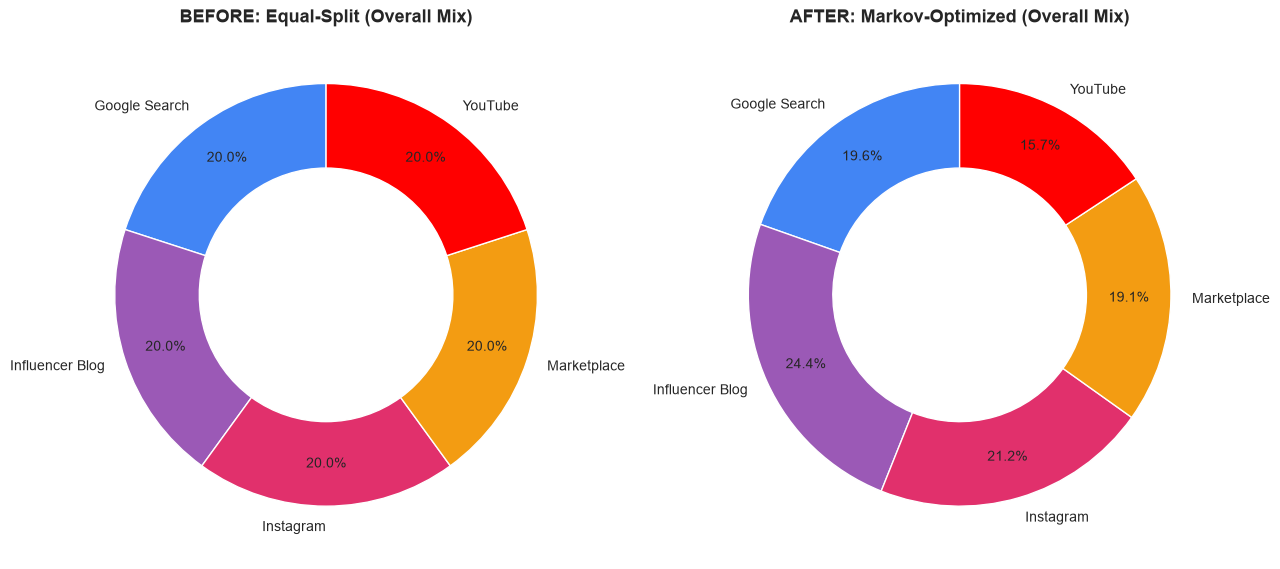

In [125]:
# ---------------------------------------------------------
# 8. DONUT CHARTS: Equal-Split vs New Allocation, OVERALL channel mix (all brands combined)
# ---------------------------------------------------------
equal_total = equal_split_matrix.sum(axis=0)
new_total = new_alloc_matrix.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, data, title in zip(axes, [equal_total, new_total], ['BEFORE: Equal-Split (Overall Mix)', 'AFTER: Markov-Optimized (Overall Mix)']):
    colors = [channel_colors[c] for c in data.index]
    wedges, texts, autotexts = ax.pie(
        data, labels=data.index, autopct=lambda p: f'{p:.1f}%', colors=colors,
        wedgeprops=dict(width=0.4), pctdistance=0.8, startangle=90
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('donut_before_after_overall.png', dpi=200)
plt.show()


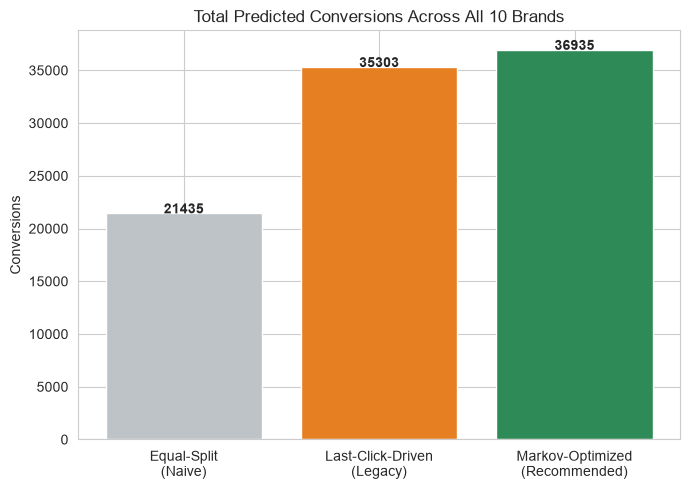


All allocation outputs and visuals saved.


In [126]:

# 9. TOTAL LIFT SUMMARY (single headline chart for the memo)
fig, ax = plt.subplots(figsize=(7,5))
totals = [comparison_summary['Naive_Equal_Split'].sum(), comparison_summary['LastClick_Driven'].sum(), comparison_summary['New_Markov_Optimized'].sum()]
labels = ['Equal-Split\n(Naive)', 'Last-Click-Driven\n(Legacy)', 'Markov-Optimized\n(Recommended)']
colors = ['#bdc3c7','#e67e22','#2e8b57']
bars = ax.bar(labels, totals, color=colors)
for bar, v in zip(bars, totals):
    ax.text(bar.get_x()+bar.get_width()/2, v+5, f"{v:.0f}", ha='center', fontweight='bold')
ax.set_title("Total Predicted Conversions Across All 10 Brands")
ax.set_ylabel("Conversions")
plt.tight_layout()
plt.savefig('total_lift_headline.png', dpi=200)
plt.show()

print("\nAll allocation outputs and visuals saved.")


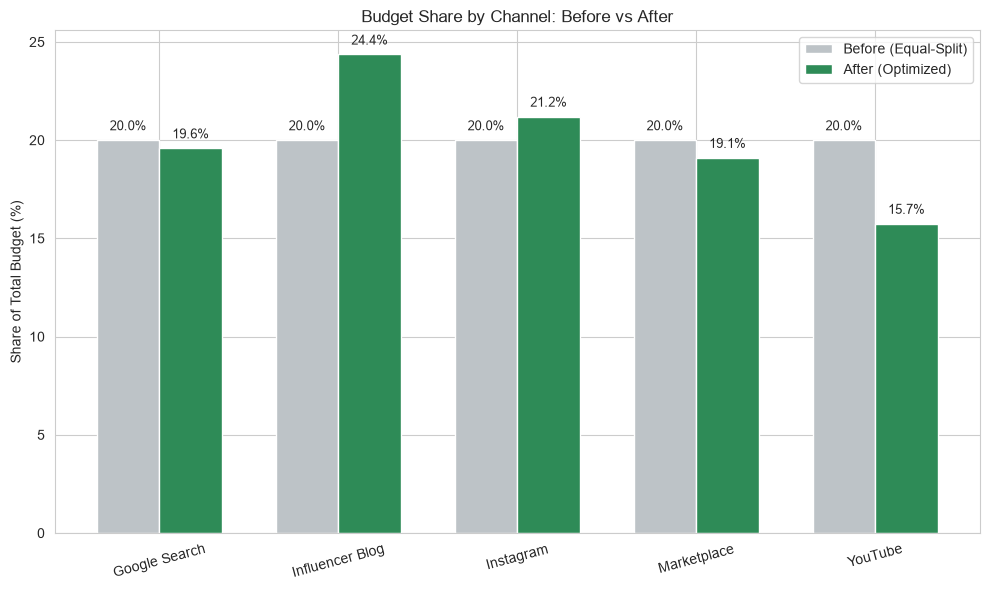

In [129]:
# ---------------------------------------------------------
# 10. % SHARE GROUPED BAR — clean comparison of channel share, Before vs After (overall)
# ---------------------------------------------------------
share_compare = pd.DataFrame({
    'Equal-Split (Before) %': (equal_total/equal_total.sum()*100),
    'Markov-Optimized (After) %': (new_total/new_total.sum()*100)
}).reindex(ALL_CHANNELS)

fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(ALL_CHANNELS))
width = 0.35
bars1 = ax.bar(x-width/2, share_compare['Equal-Split (Before) %'], width, label='Before (Equal-Split)', color='#bdc3c7')
bars2 = ax.bar(x+width/2, share_compare['Markov-Optimized (After) %'], width, label='After (Optimized)', color='#2e8b57')
for b in list(bars1)+list(bars2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.1f}%", ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(ALL_CHANNELS, rotation=15)
ax.set_ylabel("Share of Total Budget (%)")
ax.set_title("Budget Share by Channel: Before vs After")
ax.legend()
plt.tight_layout()
plt.savefig('budget_share_before_after_bar.png', dpi=200)
plt.show()

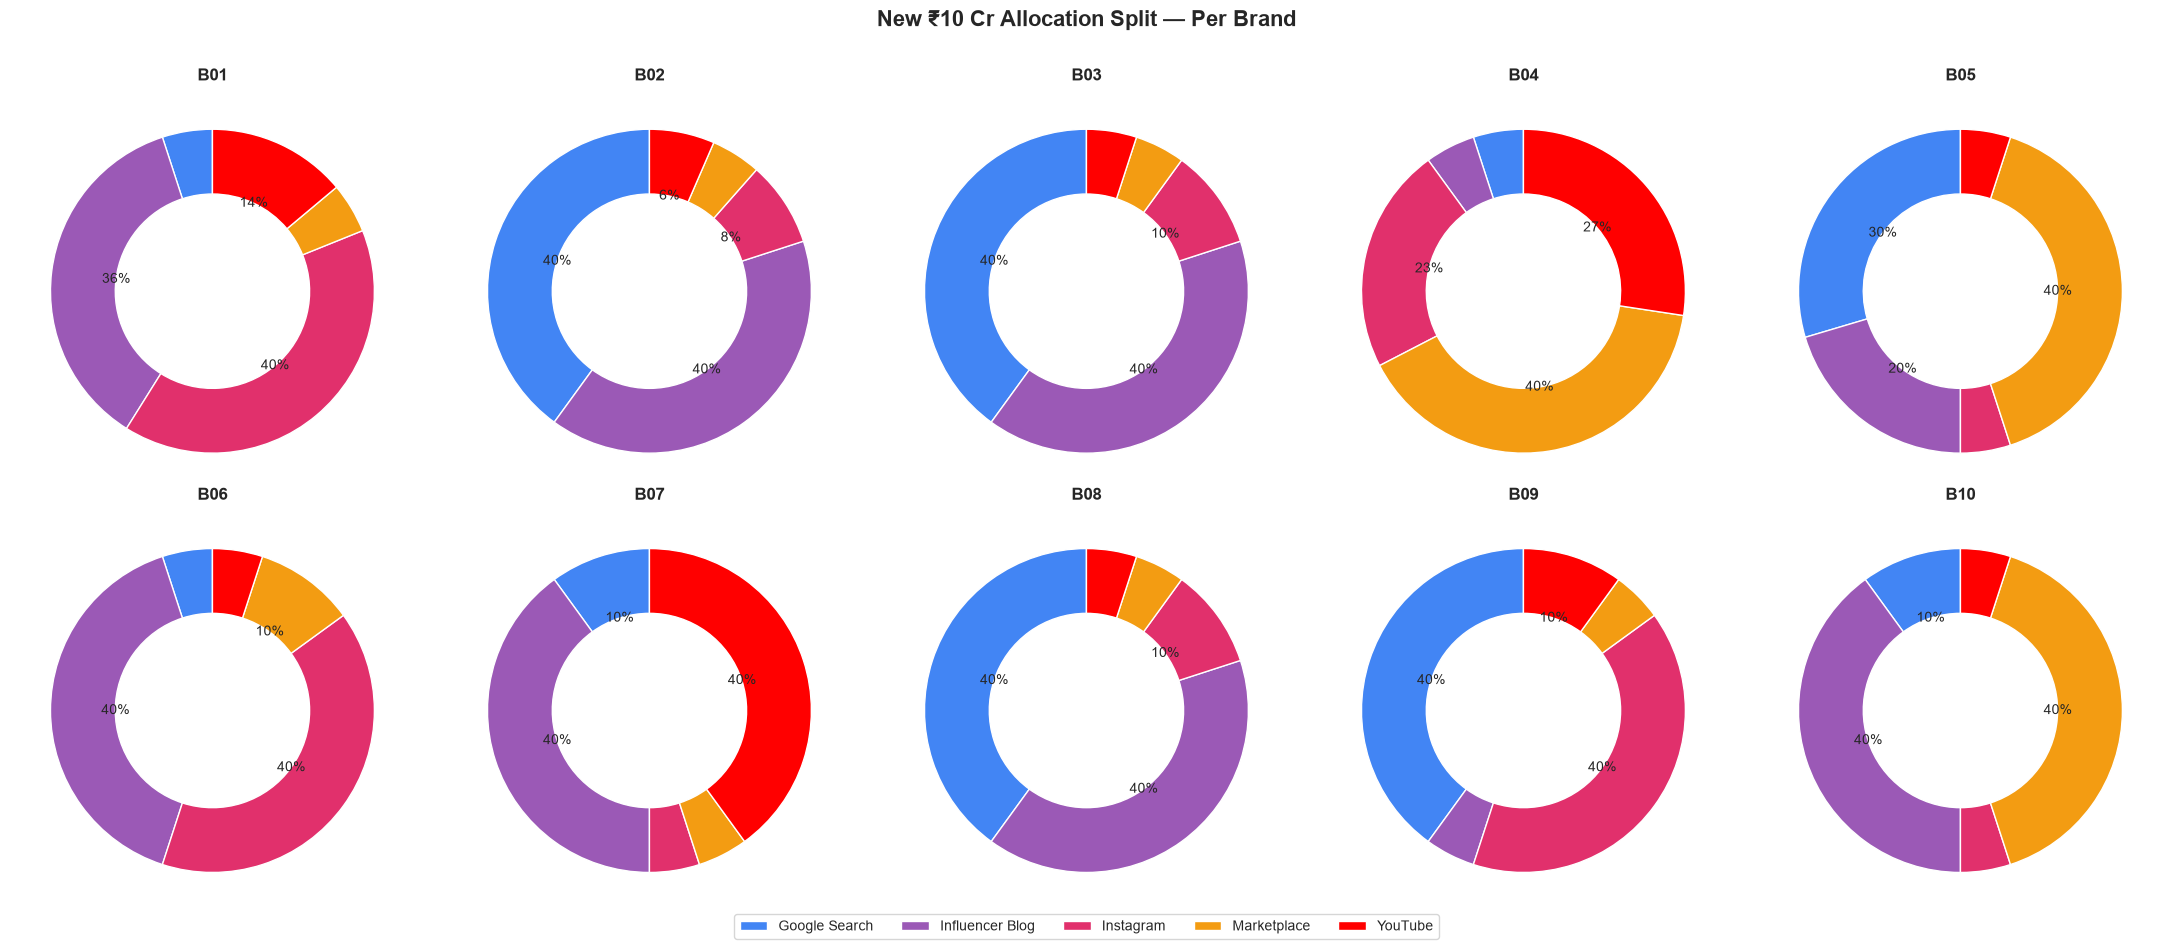

In [109]:
# ---------------------------------------------------------
# 11. PER-BRAND DONUT GRID (small multiples) — shows each brand's new ₹10 Cr split at a glance
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
for i, brand in enumerate(sorted(journeys['brand'].unique())):
    data = new_alloc_matrix.loc[brand]
    colors = [channel_colors[c] for c in data.index]
    axes[i].pie(data, colors=colors, wedgeprops=dict(width=0.4), startangle=90,
                autopct=lambda p: f'{p:.0f}%' if p > 5 else '')
    axes[i].set_title(brand, fontweight='bold')
fig.legend(ALL_CHANNELS, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("New ₹10 Cr Allocation Split — Per Brand", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('per_brand_donut_grid.png', dpi=200, bbox_inches='tight')
plt.show()

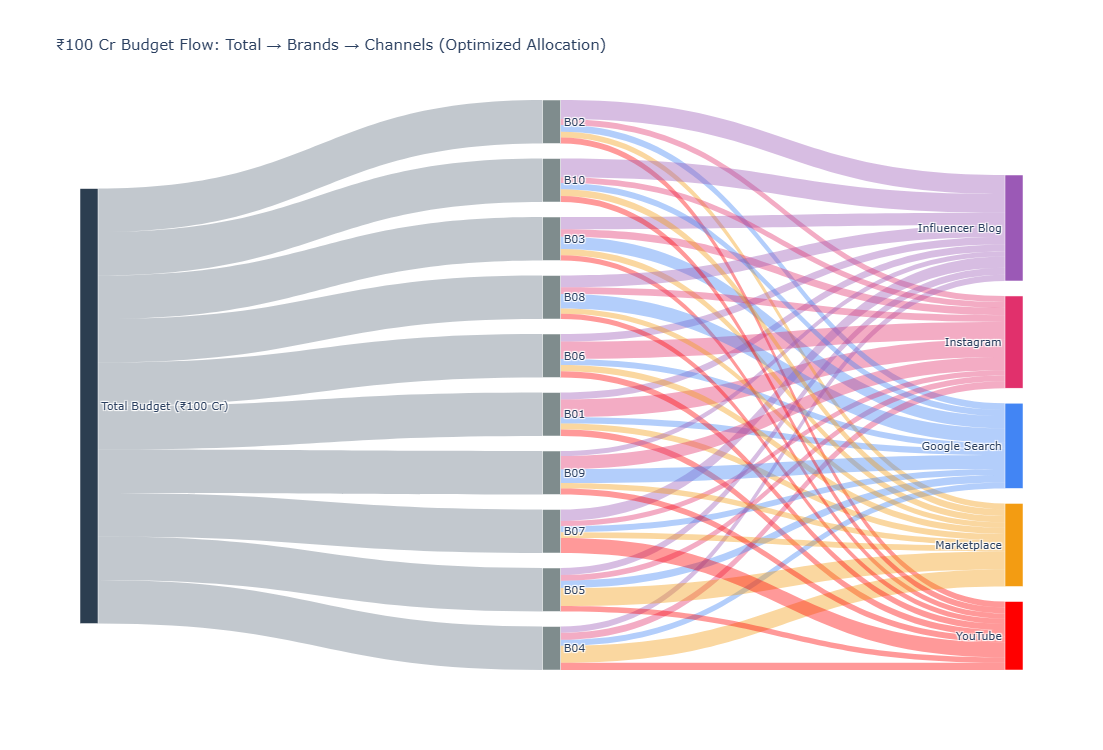

All allocation visuals saved.


In [130]:
# ---------------------------------------------------------
# 12. SANKEY: ₹100 Cr Total -> Brands -> Channels (the clearest "where the money went" visual)
# ---------------------------------------------------------
nodes = ['Total Budget (₹100 Cr)'] + brands + ALL_CHANNELS
node_idx = {n:i for i,n in enumerate(nodes)}

sources, targets, values, link_colors = [], [], [], []

# Total -> Brand
for brand in brands:
    sources.append(node_idx['Total Budget (₹100 Cr)'])
    targets.append(node_idx[brand])
    values.append(BRAND_BUDGET)
    link_colors.append('rgba(52,73,94,0.3)')

# Brand -> Channel
for brand in brands:
    for ch in ALL_CHANNELS:
        sources.append(node_idx[brand])
        targets.append(node_idx[ch])
        values.append(new_alloc_matrix.loc[brand, ch])
        link_colors.append('rgba({},{},{},0.4)'.format(
            *[int(channel_colors[ch].lstrip('#')[j:j+2],16) for j in (0,2,4)]
        ))

node_colors = ['#2c3e50'] + ['#7f8c8d']*len(brands) + [channel_colors[c] for c in ALL_CHANNELS]

fig = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=18, label=nodes, color=node_colors, line=dict(color='white', width=0.5)),
    link=dict(source=sources, target=targets, value=values, color=link_colors)
)])
fig.update_layout(title_text="₹100 Cr Budget Flow: Total → Brands → Channels (Optimized Allocation)",
                   font=dict(size=11), height=750, width=1100)
fig.show()
fig.write_html('budget_flow_sankey.html')

print("All allocation visuals saved.")


## 4. Final Verification

In [136]:
import pandas as pd
import numpy as np

OUT = '/mnt/user-data/outputs/'

# ---------------------------------------------------------
# 1. WRAP YOUR ALLOCATION LOGIC INTO A REUSABLE FUNCTION (so we can re-run at different budgets)
# ---------------------------------------------------------
def run_allocation(total_brand_budget):
    results = []
    for brand in sorted(journeys['brand'].unique()):
        allocated = {ch: 0.0 for ch in ALL_CHANNELS}
        floor = total_brand_budget * brand_floor_pct[brand]
        cap = total_brand_budget * brand_cap_pct[brand]

        for ch in ALL_CHANNELS:
            allocated[ch] = floor
        remaining = total_brand_budget - floor * len(ALL_CHANNELS)

        while remaining > 1:
            eligible = [ch for ch in ALL_CHANNELS if allocated[ch] < cap]
            if not eligible:
                break
            marg_values = np.array([get_marginal_value(brand, ch, allocated[ch]) for ch in eligible])
            marg_values = marg_values / (marg_values.max() + 1e-9)
            weights = np.exp(marg_values / TEMPERATURE)
            weights = weights / weights.sum()
            step_total = min(INCREMENT, remaining)
            step_split = weights * step_total
            for ch, s in zip(eligible, step_split):
                room = cap - allocated[ch]
                actual = min(s, room)
                allocated[ch] += actual
                remaining -= actual

        for ch in ALL_CHANNELS:
            results.append({'Brand': brand, 'Channel': ch, 'Allocation': allocated[ch]})

    df = pd.DataFrame(results).drop_duplicates(subset=['Brand','Channel'], keep='last')
    return df.pivot_table(index='Brand', columns='Channel', values='Allocation', aggfunc='sum').reindex(columns=ALL_CHANNELS)



In [137]:

# ---------------------------------------------------------
# 2. RUN AT BASELINE, -10%, +10%
# ---------------------------------------------------------
alloc_base = run_allocation(BRAND_BUDGET)
alloc_minus10 = run_allocation(BRAND_BUDGET * 0.90)
alloc_plus10 = run_allocation(BRAND_BUDGET * 1.10)

In [138]:

# ---------------------------------------------------------
# 3. RANK STABILITY CHECK: does each channel's RELATIVE share rank stay consistent across shocks?
# ---------------------------------------------------------
share_base = alloc_base.div(alloc_base.sum(axis=1), axis=0)
share_minus10 = alloc_minus10.div(alloc_minus10.sum(axis=1), axis=0)
share_plus10 = alloc_plus10.div(alloc_plus10.sum(axis=1), axis=0)

rank_base = share_base.rank(axis=1, ascending=False)
rank_minus10 = share_minus10.rank(axis=1, ascending=False)
rank_plus10 = share_plus10.rank(axis=1, ascending=False)

rank_stable = (rank_base == rank_minus10) & (rank_base == rank_plus10)
stability_pct = rank_stable.values.mean() * 100

print(f"--- Rank Stability Across ±10% Budget Shocks ---")
print(f"{stability_pct:.1f}% of Brand-Channel rankings stayed consistent across baseline / -10% / +10%.")
print("\nUnstable Brand-Channel pairs (rank changed under shock):")
print(rank_stable[~rank_stable].stack().index.tolist() if (~rank_stable).any().any() else "None")


--- Rank Stability Across ±10% Budget Shocks ---
100.0% of Brand-Channel rankings stayed consistent across baseline / -10% / +10%.

Unstable Brand-Channel pairs (rank changed under shock):
None


## (Optional)- Checking all numbers

In [146]:
import pandas as pd
import numpy as np

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("#"*90)
print("ROI LENS — FULL COMPREHENSIVE SUMMARY REPORT")
print("#"*90)

# ===========================================================
# SECTION 1: DATA CLEANING / BOT REMOVAL
# ===========================================================
print("\n" + "="*90)
print("SECTION 1: BOT DETECTION & DATA CLEANING")
print("="*90)

raw_users = touch['User_ID'].nunique()
clean_users = touch_clean['User_ID'].nunique()
raw_events = len(touch)
clean_events = len(touch_clean)

print(f"Raw users: {raw_users:,} | Cleaned users: {clean_users:,} | Bots removed: {raw_users-clean_users:,} ({(raw_users-clean_users)/raw_users*100:.2f}%)")
print(f"Raw events: {raw_events:,} | Cleaned events: {clean_events:,} | Events removed: {raw_events-clean_events:,} ({(raw_events-clean_events)/raw_events*100:.2f}%)")

# ===========================================================
# SECTION 2: FUNNEL & CONVERSION (Overall + Brand-wise)
# ===========================================================
print("\n" + "="*90)
print("SECTION 2: FUNNEL & CONVERSION RATES")
print("="*90)

print("\n--- Overall Funnel ---")
print(overall_funnel)

print(f"\nOverall Conversion Rate: {overall_cvr:.2f}%")

print("\n--- Conversion Rate by Brand ---")
print(brand_cvr.round(2))

print("\n--- Drop-off % by Brand x Stage ---")
print(pivot_dropoff.round(2))

# ===========================================================
# SECTION 3: MARKOV ATTRIBUTION vs LAST-CLICK vs FIRST-CLICK
# ===========================================================
print("\n" + "="*90)
print("SECTION 3: MARKOV ATTRIBUTION — TRUE CREDIT vs LEGACY MODELS")
print("="*90)

print(f"\nOverall Baseline Conversion Probability (Markov): {overall_baseline_cvr:.4f}")

print("\n--- Overall Attribution Comparison (Markov vs Last-Click vs First-Click) ---")
print(comparison_sorted.round(2))

print("\n--- Overrated Channels (Last-Click gives MORE credit than Markov truth) ---")
print(overrated_channels[['Markov_Conversions','LastClick_Conversions','Overrated_by_LastClick']].round(2))

print("\n--- Underrated Channels (Markov gives MORE credit than Last-Click) ---")
print(underrated_channels[['Markov_Conversions','LastClick_Conversions','Overrated_by_LastClick']].round(2))

print("\n--- Primer vs Closer Role (Overall) ---")
print(primer_closer_df.round(3))

print("\n--- Brand x Channel: Markov Attribution Weight ---")
print(brand_attr_matrix.round(3))

print("\n--- Brand x Channel: Markov Attributed Conversions ---")
print(brand_attr_conv_matrix.round(1))

print("\n--- First-Touch % by Brand x Channel ---")
print(first_touch_matrix.round(1))

print("\n--- Last-Touch % by Brand x Channel ---")
print(last_touch_matrix.round(1))

print("\n--- Primer/Closer Role Label Matrix (Brand x Channel) ---")
print(role_matrix)

# ===========================================================
# SECTION 4: SPEND & TRUE CPA
# ===========================================================
print("\n" + "="*90)
print("SECTION 4: SPEND & TRUE CPA ANALYSIS")
print("="*90)

print(f"\nTotal Spend: ₹{total_budget:,.2f}  (Expected ₹100 Cr | Deviation: {(total_budget-1e9)/1e9*100:.2f}%)")

print("\n--- Spend by Brand x Channel (₹) ---")
print(spend_by_brand_channel.round(0))

print("\n--- CONSERVATION CHECK (must be ~0) ---")
print(conservation.round(2))

print("\n--- True CPA (₹ per Conversion, Markov Basis) — Brand x Channel ---")
print(true_cpa_matrix.round(2))

print("\n--- Last-Click CPA (₹ per Conversion) — Brand x Channel ---")
print(lastclick_cpa_matrix.round(2))

print("\n--- Full CPA Comparison Table (with Roles & Shares) ---")
print(cpa_df.round(2))

print("\n--- Channel Efficiency Classification (Avg True CPA, Overall) ---")
print(pd.DataFrame({'Avg_True_CPA': channel_avg_true_cpa.round(2), 'Tier': channel_efficiency}))

print("\n--- Blended True CPA by Brand (Overall) ---")
print(brand_blended_cpa.round(2))

print("\n--- Round-Number Spend Anomalies Flagged ---")
print(round_flags[['Campaign_ID','Brand_ID','Channel','Total_Budget_Allocated']])

# ===========================================================
# SECTION 5: AD FATIGUE / DIMINISHING RETURNS
# ===========================================================
print("\n" + "="*90)
print("SECTION 5: AD FATIGUE / DIMINISHING RETURNS")
print("="*90)

print(f"\nReliable fits (R² > 0.3): {len(fatigue_df)} brand-channel pairs")
print(fatigue_df[['Brand','Channel','Best_Model','R2','Total_Spend','Total_Conversions',
                  'Marginal_Conv_per_Rupee_at_CurrentSpend','Fatigue_Flag']].round(4))

print(f"\nFatigue-flagged pairs: {fatigue_df['Fatigue_Flag'].sum()} out of {len(fatigue_df)}")

# ===========================================================
# SECTION 6: BUDGET ALLOCATION — BEFORE vs AFTER
# ===========================================================
print("\n" + "="*90)
print("SECTION 6: BUDGET ALLOCATION — BEFORE vs AFTER")
print("="*90)

print("\n--- BEFORE: Naive Equal-Split (₹ per Brand x Channel) ---")
print(equal_split_matrix.round(0))

print("\n--- BEFORE: Last-Click-Driven Allocation (₹ per Brand x Channel) ---")
print(lastclick_alloc_matrix.round(0))

print("\n--- AFTER: Recommended Markov-Optimized Allocation (₹ per Brand x Channel) ---")
print(new_alloc_matrix.round(0))

print("\n--- Row Sum Check (each brand must total ₹10,00,00,000) ---")
print(new_alloc_matrix.sum(axis=1).round(2))

print("\n--- AFTER: Allocation as % Share per Brand x Channel ---")
new_share_matrix = new_alloc_matrix.div(new_alloc_matrix.sum(axis=1), axis=0) * 100
print(new_share_matrix.round(2))

print("\n--- Overall Channel Mix: Before vs After (₹ Total Across All Brands) ---")
mix_compare = pd.DataFrame({
    'Equal_Split_Total': equal_split_matrix.sum(axis=0),
    'LastClick_Driven_Total': lastclick_alloc_matrix.sum(axis=0),
    'New_Optimized_Total': new_alloc_matrix.sum(axis=0)
})
mix_compare['Equal_Split_%'] = mix_compare['Equal_Split_Total']/mix_compare['Equal_Split_Total'].sum()*100
mix_compare['LastClick_%'] = mix_compare['LastClick_Driven_Total']/mix_compare['LastClick_Driven_Total'].sum()*100
mix_compare['New_Optimized_%'] = mix_compare['New_Optimized_Total']/mix_compare['New_Optimized_Total'].sum()*100
print(mix_compare.round(2))

# ===========================================================
# SECTION 7: PREDICTED CONVERSION LIFT
# ===========================================================
print("\n" + "="*90)
print("SECTION 7: PREDICTED CONVERSION LIFT — NEW vs BASELINES")
print("="*90)

print("\n--- Predicted Conversions per Brand (Equal-Split vs Last-Click vs New) ---")
print(comparison_summary.round(2))

print(f"\nTOTAL Predicted Conversions:")
print(f"  Equal-Split (Naive):     {comparison_summary['Naive_Equal_Split'].sum():,.1f}")
print(f"  Last-Click-Driven:       {comparison_summary['LastClick_Driven'].sum():,.1f}")
print(f"  New Markov-Optimized:    {comparison_summary['New_Markov_Optimized'].sum():,.1f}")
print(f"  Lift vs Equal-Split:     {(comparison_summary['New_Markov_Optimized'].sum()/comparison_summary['Naive_Equal_Split'].sum()-1)*100:.2f}%")
print(f"  Lift vs Last-Click:      {(comparison_summary['New_Markov_Optimized'].sum()/comparison_summary['LastClick_Driven'].sum()-1)*100:.2f}%")

# ===========================================================
# SECTION 8: SENSITIVITY / VALIDATION
# ===========================================================
print("\n" + "="*90)
print("SECTION 8: SENSITIVITY (±10% BUDGET SHOCK) & FREQ-CAP FLAGS")
print("="*90)

print(f"\nRank Stability Across ±10% Budget Shocks: {stability_pct:.2f}%")


print("\n--- FREQUENCY-CAP CANDIDATES (sharp fatigue detected) ---")
print(freq_cap_df[['Brand','Channel','Best_Model','R2','Total_Spend','Marginal_Conv_per_Rupee_at_CurrentSpend']].round(4))

# ===========================================================
# SECTION 9: HEADLINE NUMBERS (single-glance scorecard)
# ===========================================================
print("\n" + "="*90)
print("SECTION 9: HEADLINE SCORECARD")
print("="*90)

headline = pd.DataFrame({
    'Metric': [
        'Total Users (Raw -> Cleaned)',
        'Bots Removed (%)',
        'Overall Conversion Rate (%)',
        'Total Spend (₹)',
        'Cheapest Channel (Avg True CPA)',
        'Most Expensive Channel (Avg True CPA)',
        'Best Brand (Lowest Blended CPA)',
        'Worst Brand (Highest Blended CPA)',
        'Most Overrated Channel (Last-Click vs Markov)',
        'Most Underrated Channel (Last-Click vs Markov)',
        'Total Predicted Conversions (New Allocation)',
        'Lift vs Equal-Split (%)',
        'Lift vs Last-Click-Driven (%)',
        'Rank Stability Under ±10% Shock (%)',
        'Frequency-Cap Candidates (count)',
    ],
    'Value': [
        f"{raw_users:,} -> {clean_users:,}",
        f"{(raw_users-clean_users)/raw_users*100:.2f}%",
        f"{overall_cvr:.2f}%",
        f"₹{total_budget:,.0f}",
        channel_avg_true_cpa.idxmin(),
        channel_avg_true_cpa.idxmax(),
        brand_blended_cpa.idxmin(),
        brand_blended_cpa.idxmax(),
        overrated_channels.index[0] if len(overrated_channels) else 'None',
        underrated_channels.index[0] if len(underrated_channels) else 'None',
        f"{comparison_summary['New_Markov_Optimized'].sum():,.0f}",
        f"{(comparison_summary['New_Markov_Optimized'].sum()/comparison_summary['Naive_Equal_Split'].sum()-1)*100:.2f}%",
        f"{(comparison_summary['New_Markov_Optimized'].sum()/comparison_summary['LastClick_Driven'].sum()-1)*100:.2f}%",
        f"{stability_pct:.2f}%",
        len(freq_cap_df),
    ]
})
print(headline.to_string(index=False))

print("\n" + "#"*90)
print("END OF REPORT")
print("#"*90)

##########################################################################################
ROI LENS — FULL COMPREHENSIVE SUMMARY REPORT
##########################################################################################

SECTION 1: BOT DETECTION & DATA CLEANING
Raw users: 100,000 | Cleaned users: 97,926 | Bots removed: 2,074 (2.07%)
Raw events: 566,510 | Cleaned events: 371,786 | Events removed: 194,724 (34.37%)

SECTION 2: FUNNEL & CONVERSION RATES

--- Overall Funnel ---
Impression     97926
Click          23440
Add-to-Cart     8325
Purchase        5445
dtype: int64

Overall Conversion Rate: 5.56%

--- Conversion Rate by Brand ---
brand
B07   16.53
B02   12.80
B01    7.08
B04    3.21
B10    3.13
B08    3.11
B03    3.09
B06    2.96
B09    2.09
B05    1.64
Name: converted, dtype: float64

--- Drop-off % by Brand x Stage ---
stage  Impression  Click  Add-to-Cart  Purchase
brand                                          
B01          0.00  74.67        59.86     30.35
B02          